使用デバイス: cpu
Hybrid_CNN5_FC の重みを読み込みました。

テストデータ全件の評価を開始します... (モデル: Hybrid_CNN5_FC, Top-K: 130)
評価が完了しました。


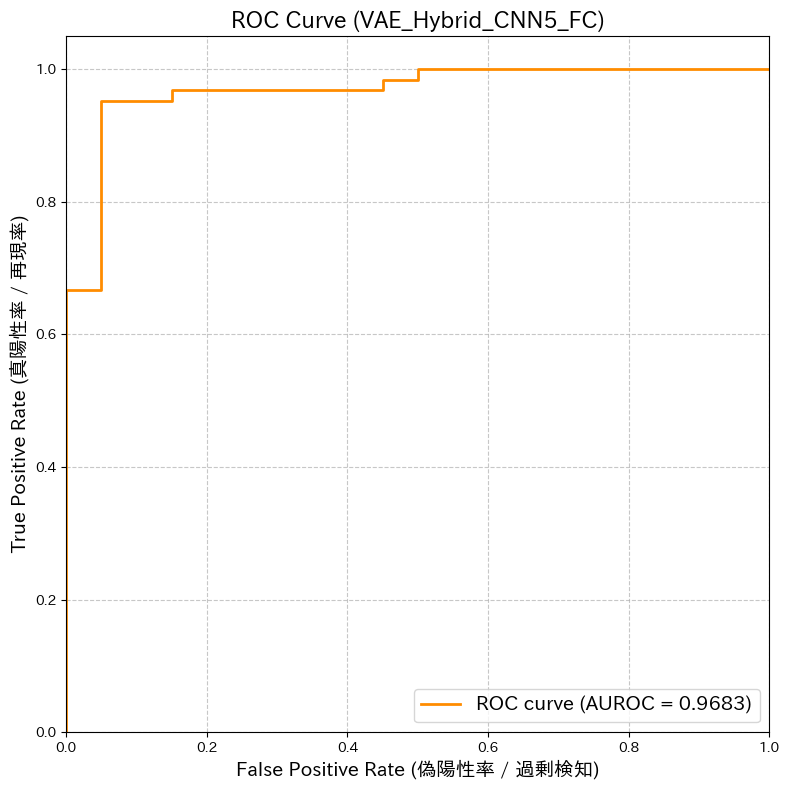


[VAE_Hybrid_CNN5_FC] AUROC: 0.9683

[自動しきい値設定: F1スコア最大化]
-> 最適しきい値: 0.8772 (Max F1: 0.9677)


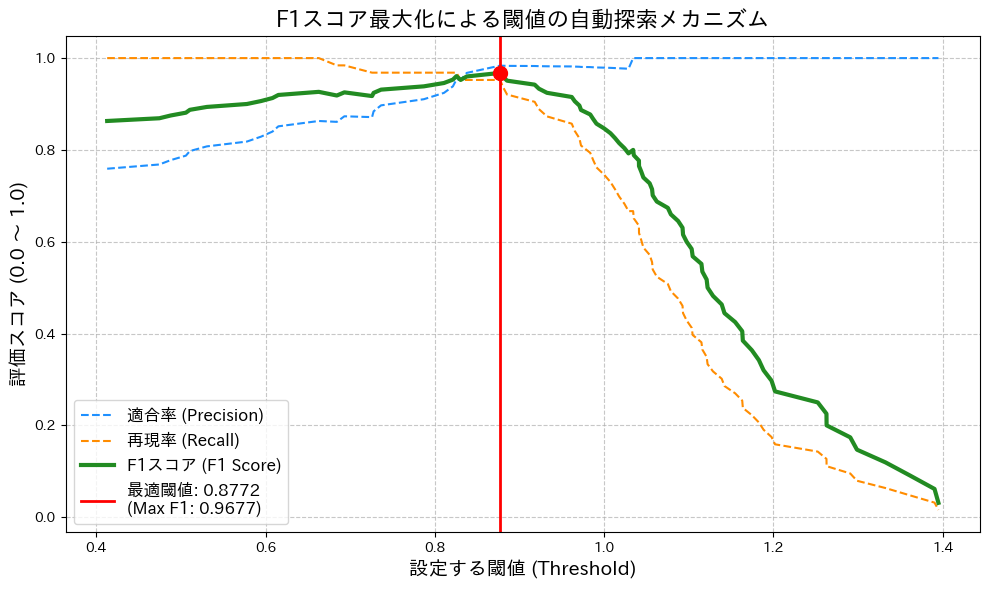


--- 定量評価結果 (Hybrid_CNN5_FC) ---
設定閾値: 0.8772
正解率 (Accuracy)  : 93.98%
適合率 (Precision) : 98.33%
再現率 (Recall)    : 93.65%
F値 (F1-score)     : 95.93%



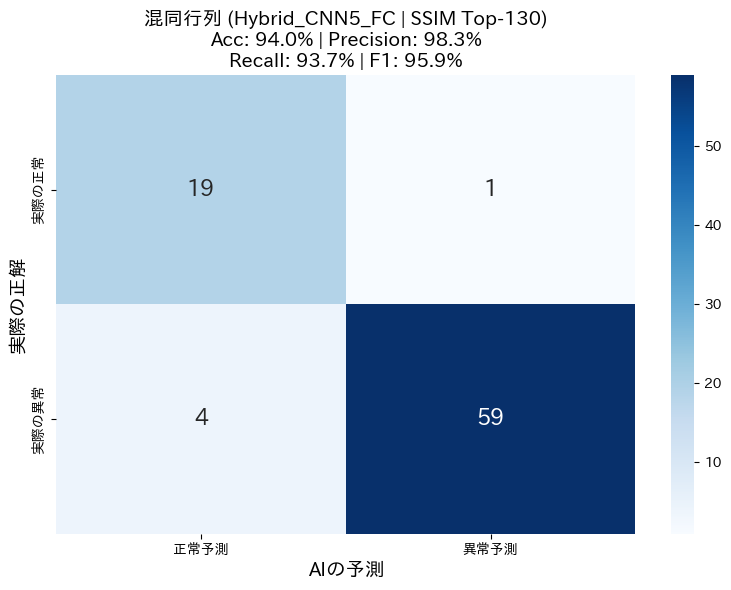

<Figure size 1000x600 with 0 Axes>

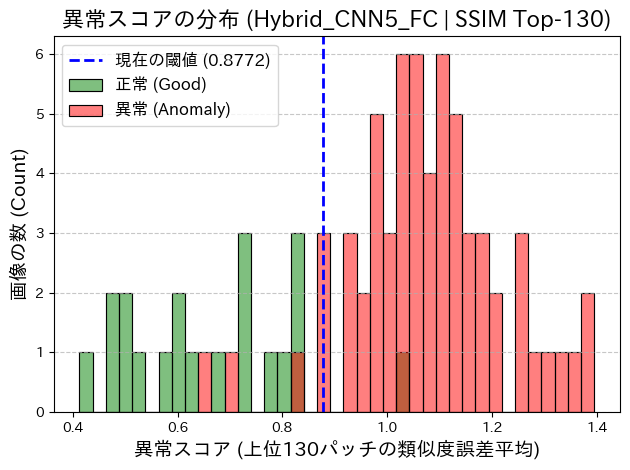


--- パターン別の代表例を可視化します ---

【1. TN: 正常を「正常」と正しく判断】 : 該当 19 件中 2 件を表示


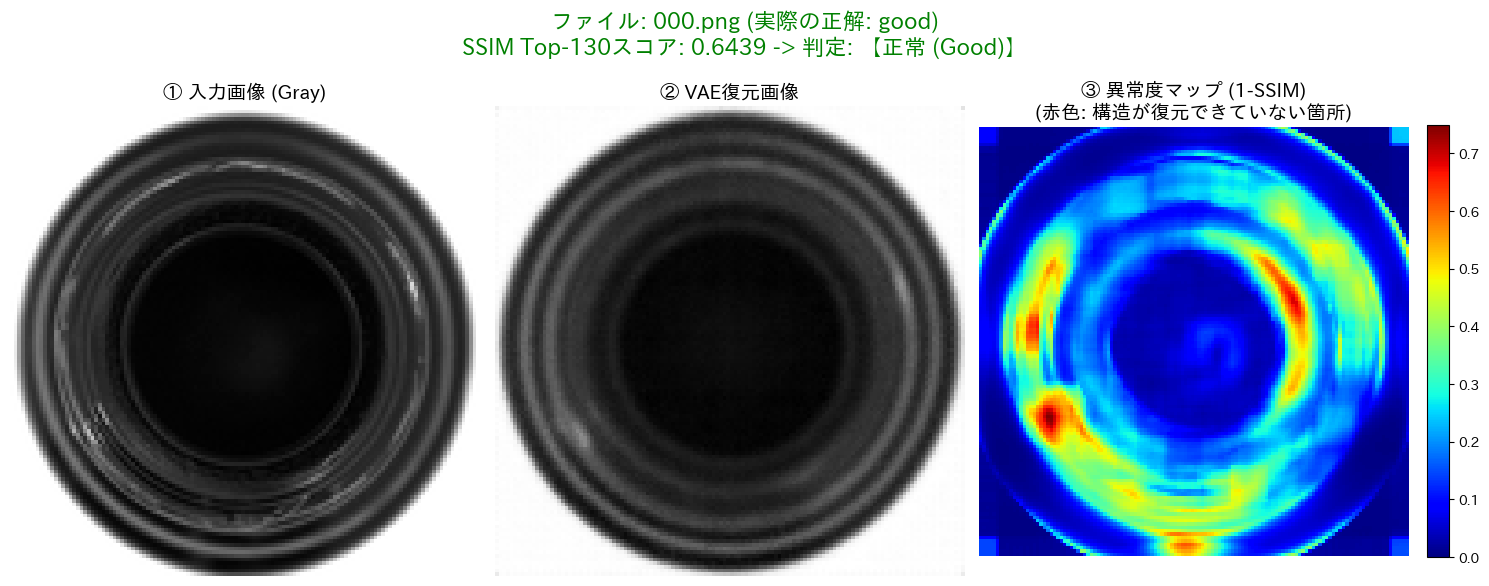

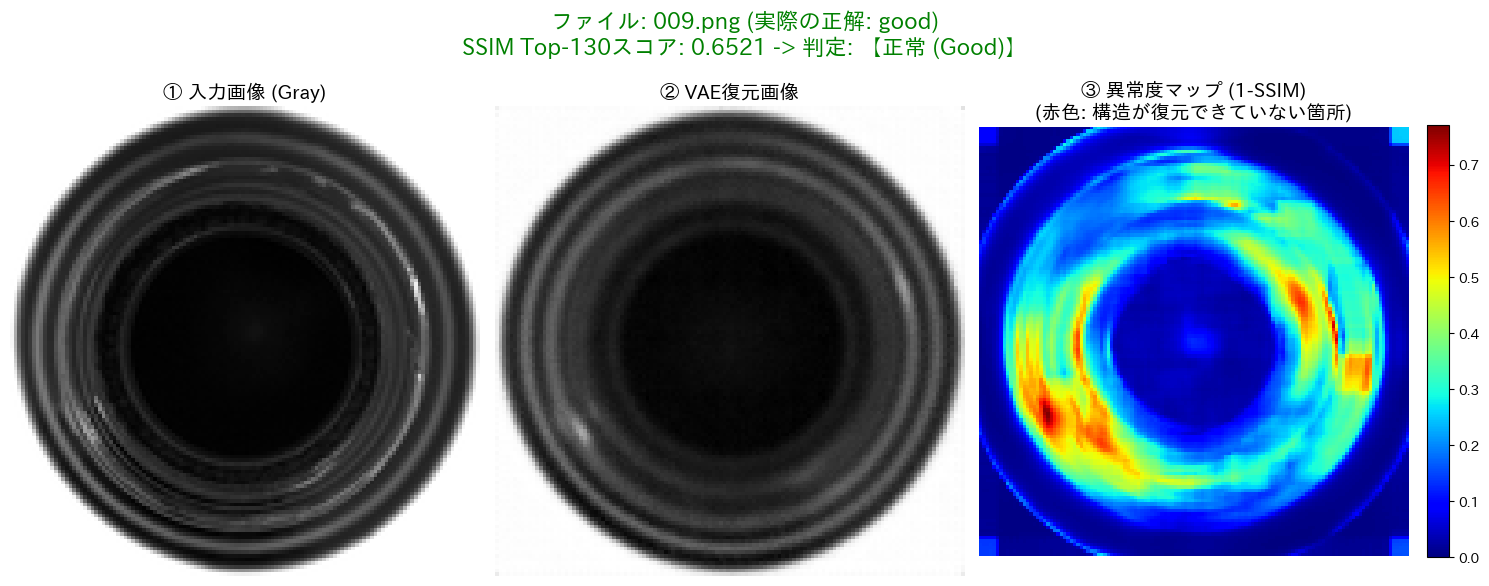


【2. FP: 正常を「異常」と誤って判断 (過剰検知)】 : 該当 1 件中 1 件を表示


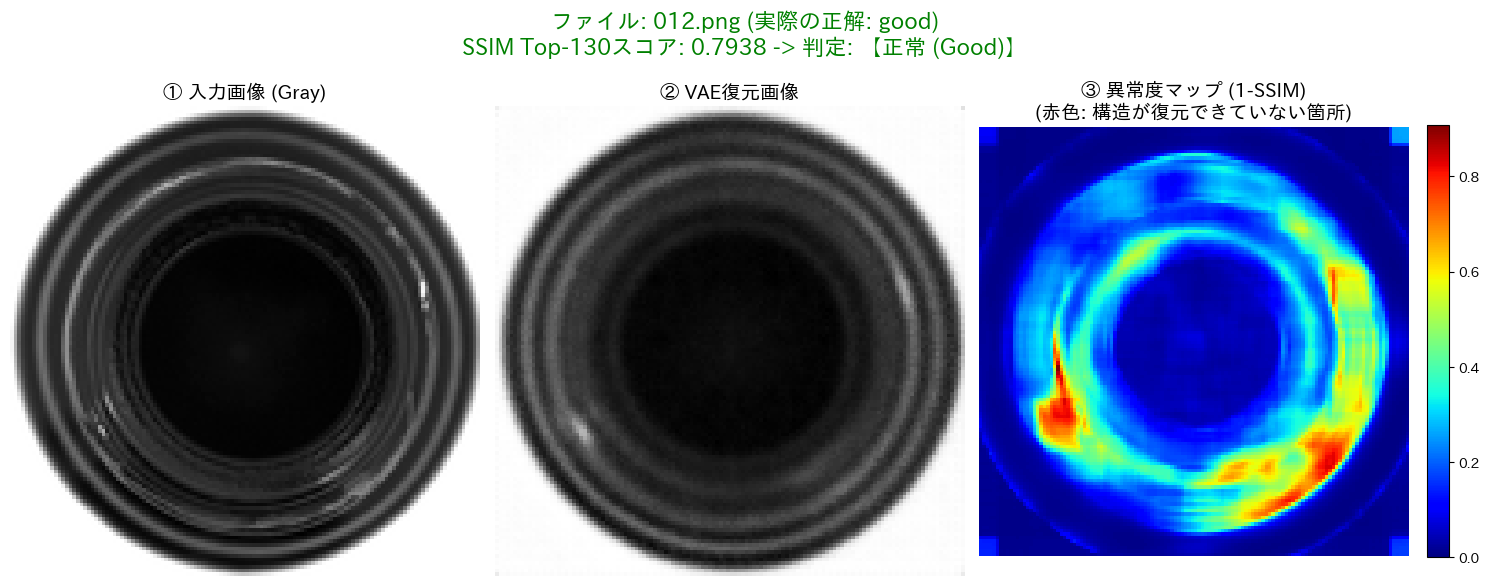


【3. FN: 異常を「正常」と誤って判断 (見逃し)】 : 該当 4 件中 2 件を表示


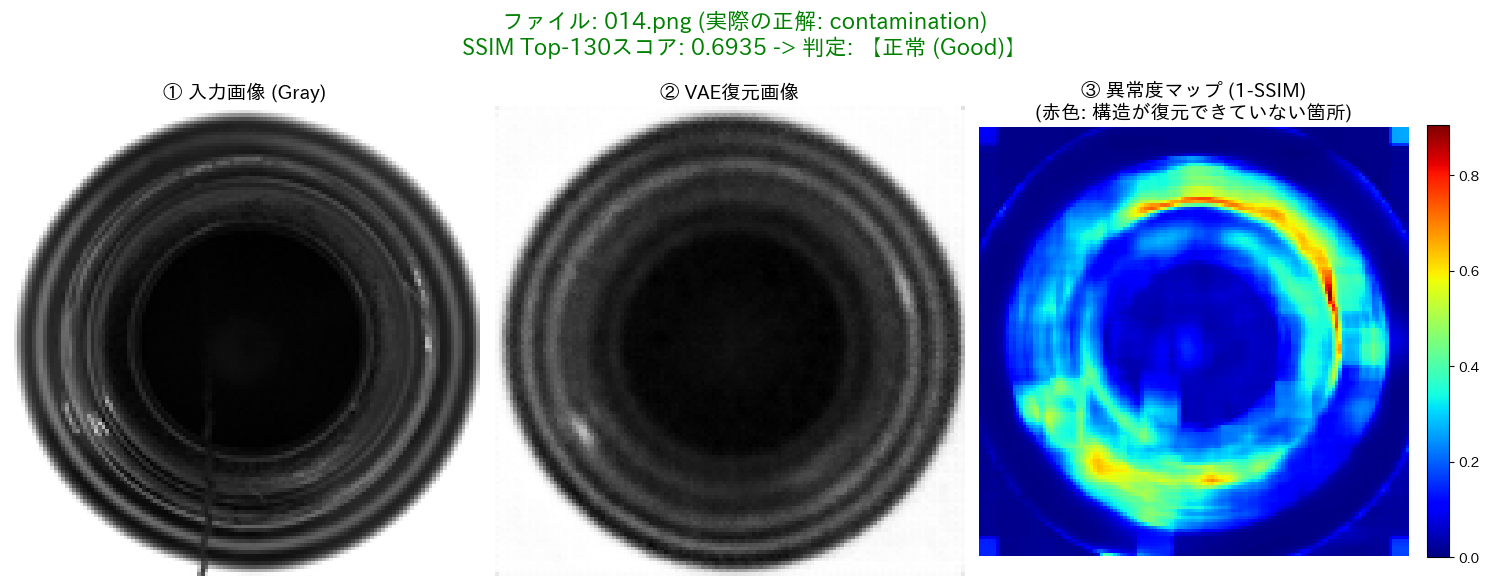

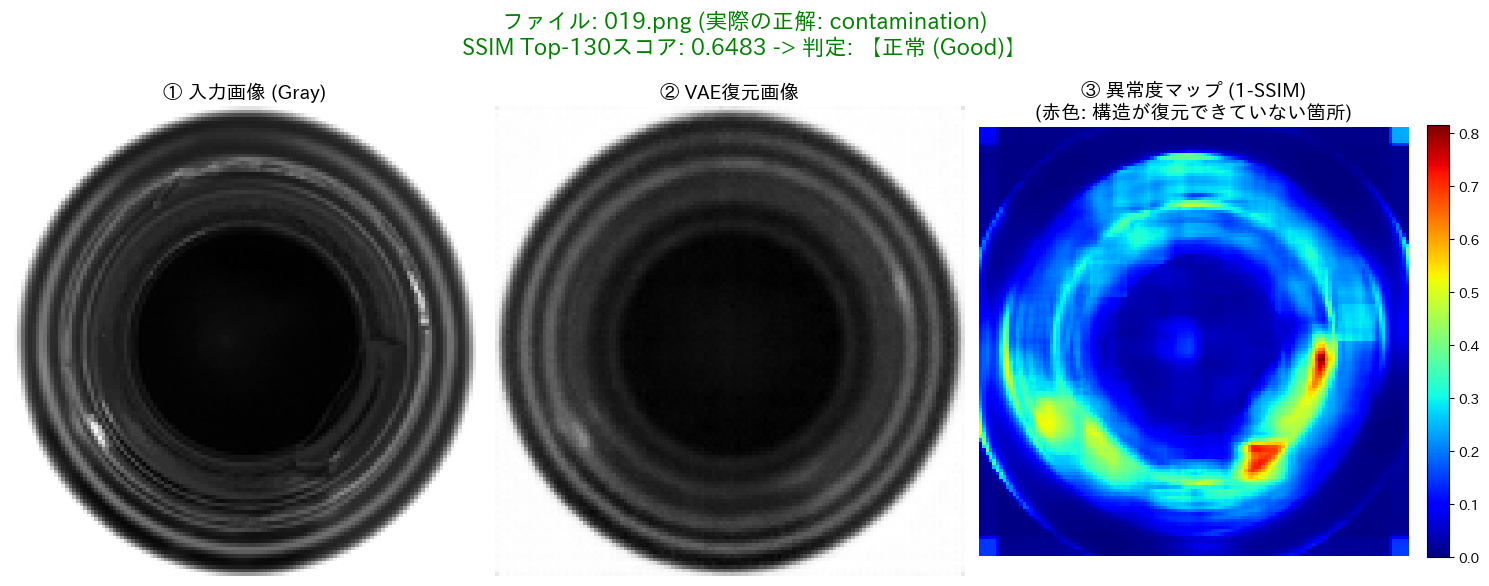


【4. TP: 異常を「異常」と正しく判断】 : 該当 59 件中 2 件を表示


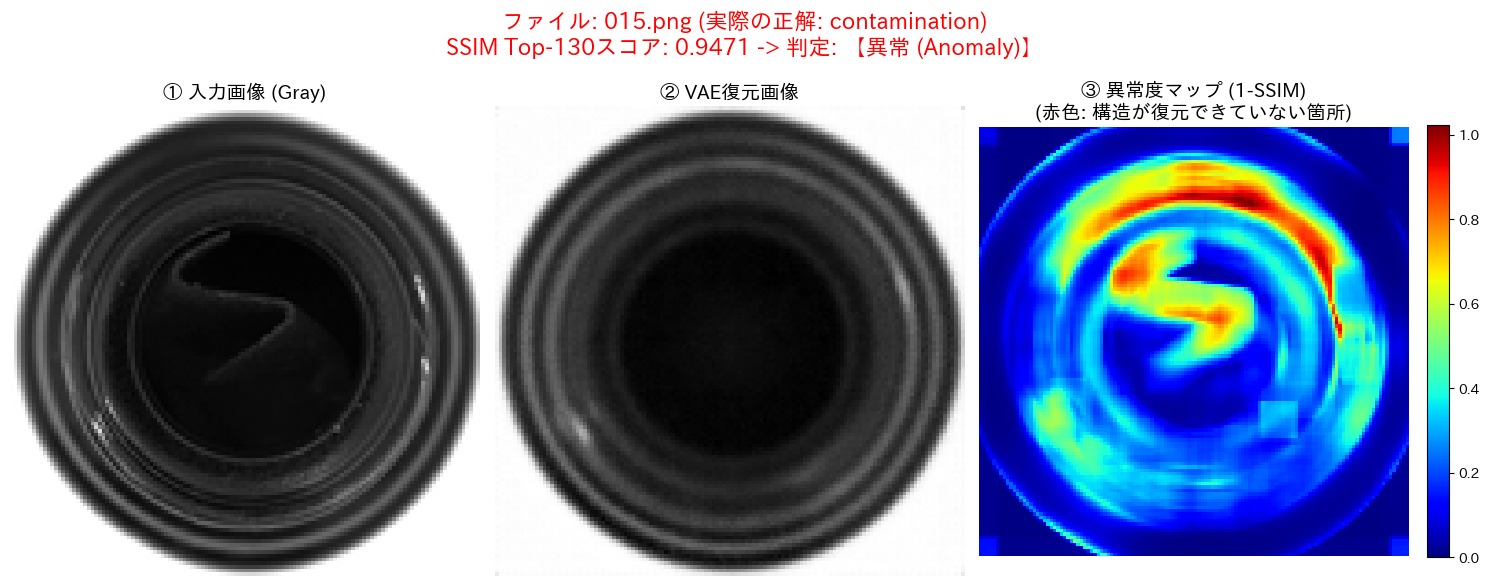

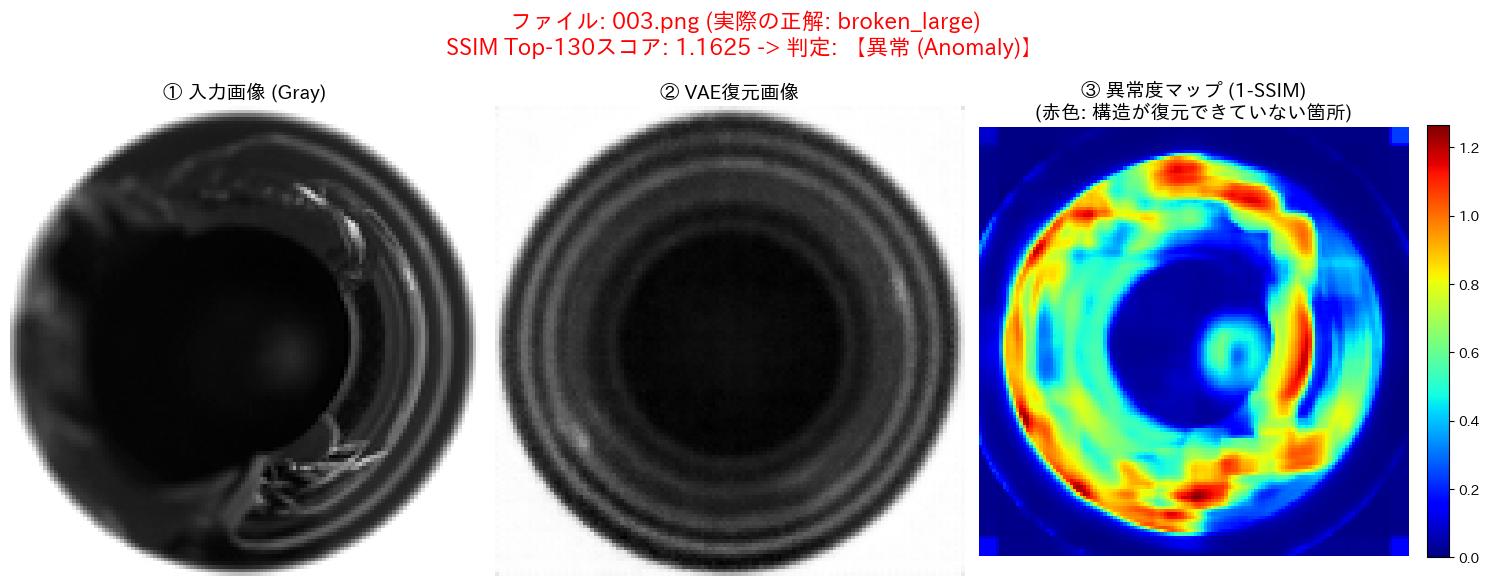


すべての検証プロセスが完了しました。


In [8]:
# =====================================================================
# 検証用スクリプト: ハイブリッドモデル（Hybrid_CNN5_FC）専用
# ---------------------------------------------------------------------
# - 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# - 閾値設定: F1スコアを最大化する閾値の自動探索
# - 評価指標: AUROC, F1-score, Precision, Recall, Accuracy
# =====================================================================

import random
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score, 
    precision_score, f1_score, precision_recall_curve, roc_curve, auc
)

# 日本語フォントの文字化け対策
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義
# =====================================================================

# 学習時と同一の前処理パイプライン
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_Hybrid_CNN_FC(nn.Module):
    """
    CNNの空間的特徴抽出と、全結合層(FC)の全体的特徴の圧縮を組み合わせたハイブリッドVAE
    """
    def __init__(self, latent_dim=64):
        super(VAE_Hybrid_CNN_FC, self).__init__()
        
        # --- エンコーダ前半: CNN_Deep5（空間圧縮: 128x128 -> 4x4） ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256), nn.ReLU()
        )
        
        # --- エンコーダ後半: FC_Only（段階的圧縮: 4096次元 -> 128次元） ---
        self.encoder_fc = nn.Sequential(
            nn.Linear(256 * 4 * 4, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        # 潜在空間へのマッピング
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # --- デコーダ前半: FC_Only（段階的復元: 64次元 -> 4096次元） ---
        self.decoder_fc = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 256 * 4 * 4), nn.ReLU()
        )
        
        # --- デコーダ後半: CNN_Deep5（空間復元: 4x4 -> 128x128） ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128), nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64), nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32), nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16), nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        h = self.encoder_fc(h)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        # 潜在変数の発散(KLD爆発)を防ぐ安全装置
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4) 
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar


# =====================================================================
# 2. 評価・解析・可視化用 関数群
# =====================================================================

def evaluate_dataset(model, test_dir, device, top_k=130):
    """データセット全体を推論し、正解ラベル、スコア、ファイルパスを収集する"""
    model.eval()
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\nデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: Hybrid_CNN5_FC, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)

                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                # SSIMによる異常度マップの生成
                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                # 異常度上位Kパッチの平均をスコアとして採用
                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                y_true.append(true_label)
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    return np.array(y_true), np.array(scores), all_image_paths


def plot_roc_curve(y_true, scores, model_name="VAE Model"):
    """ROC曲線の描画とAUROCの計算を行う"""
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUROC = {roc_auc:.4f})')
    # plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUROC = 0.5)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (偽陽性率 / 過剰検知)', fontsize=14)
    plt.ylabel('True Positive Rate (真陽性率 / 再現率)', fontsize=14)
    plt.title(f'ROC Curve ({model_name})', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print(f"\n[{model_name}] AUROC: {roc_auc:.4f}")
    return roc_auc


def compute_optimal_threshold_f1(y_true, scores):
    """PR曲線からF1スコアが最大となる最適閾値を自動計算する"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    
    # ゼロ除算回避のため微小値 1e-10 を加算
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"\n[自動しきい値設定: F1スコア最大化]")
    print(f"-> 最適しきい値: {optimal_threshold:.4f} (Max F1: {f1_scores[optimal_idx]:.4f})")
    
    return optimal_threshold


def plot_f1_optimization(y_true, scores):
    """閾値の変化に対する各種スコアの推移と、最適閾値のポイントを可視化する"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    max_f1 = f1_scores[optimal_idx]

    plt.figure(figsize=(10, 6))
    
    plt.plot(thresholds, precisions[:-1], label='適合率 (Precision)', color='dodgerblue', linestyle='--')
    plt.plot(thresholds, recalls[:-1], label='再現率 (Recall)', color='darkorange', linestyle='--')
    plt.plot(thresholds, f1_scores[:-1], label='F1スコア (F1 Score)', color='forestgreen', linewidth=3)
    
    plt.axvline(x=optimal_threshold, color='red', linestyle='-', linewidth=2, 
                label=f'最適閾値: {optimal_threshold:.4f}\n(Max F1: {max_f1:.4f})')
    plt.scatter(optimal_threshold, max_f1, color='red', s=100, zorder=5) 

    plt.title('F1スコア最大化による閾値の自動探索メカニズム', fontsize=16, fontweight='bold')
    plt.xlabel('設定する閾値 (Threshold)', fontsize=14)
    plt.ylabel('評価スコア (0.0 〜 1.0)', fontsize=14)
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    """混同行列と定量評価指標(正解率・適合率・再現率・F値)を描画する"""
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (Hybrid_CNN5_FC) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    title_str = (f"混同行列 (Hybrid_CNN5_FC | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_score_distribution(y_true, scores, threshold, top_k=130):
    """正常画像と異常画像の異常スコア分布(ヒストグラム)を描画する"""
    plt.figure(figsize=(10, 6))
    plt.tight_layout()
    plt.show()


    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold:.4f})')

    plt.title(f"異常スコアの分布 (Hybrid_CNN5_FC | SSIM Top-{top_k})", fontsize=16, fontweight='bold')
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    """1枚の画像を推論し、入力・復元・異常度マップの3パネルで可視化する"""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


# =====================================================================
# 3. 実行ブロック
# =====================================================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    # --- モデルのインスタンス化と重みのロード ---
    model = VAE_Hybrid_CNN_FC(latent_dim=64).to(device)
    MODEL_PATH = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\saved_models\vae_Hybrid_CNN5_FC_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"Hybrid_CNN5_FC の重みを読み込みました。\n")

    # --- テスト設定 ---
    TEST_DIR = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\data\bottle\test"
    TOP_K = 130

    # --- 検証プロセスの実行 ---

    # 1. 全画像の異常スコアを算出
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. AUROCの計算と描画（閾値非依存の性能評価）
    auroc_score = plot_roc_curve(y_true, scores, model_name="VAE_Hybrid_CNN5_FC")

    # 3. F1スコアが最大となる最適閾値を探索
    THRESHOLD = compute_optimal_threshold_f1(y_true, scores)
    
    # 4. F1最適化の推移を図解
    plot_f1_optimization(y_true, scores)

    # 5. 決定した閾値に基づく最終的な予測ラベルを作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 6. 定量評価・スコア分布の描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)

    # --- 各判定パターン（TP/FP/TN/FN）ごとの画像確認 ---
    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")

使用デバイス: cpu
VAE_FC の重みを読み込みました。

テストデータ全件の評価を開始します... (モデル: VAE_FC, Top-K: 130)
評価が完了しました。


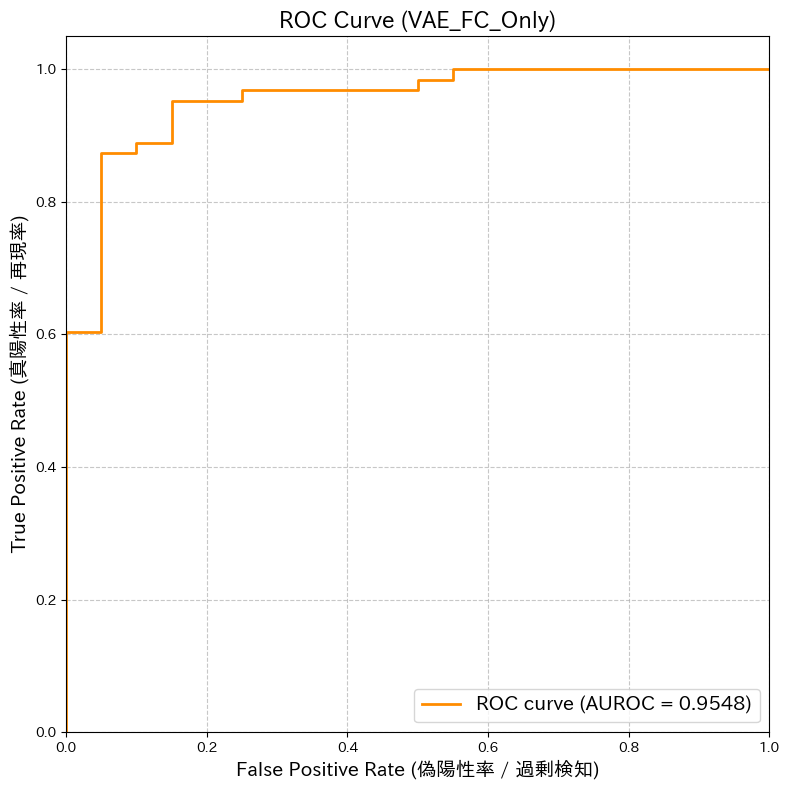


[VAE_FC_Only] AUROC: 0.9548

[自動しきい値設定: F1スコア最大化]
-> 最適しきい値: 0.8847 (Max F1: 0.9524)


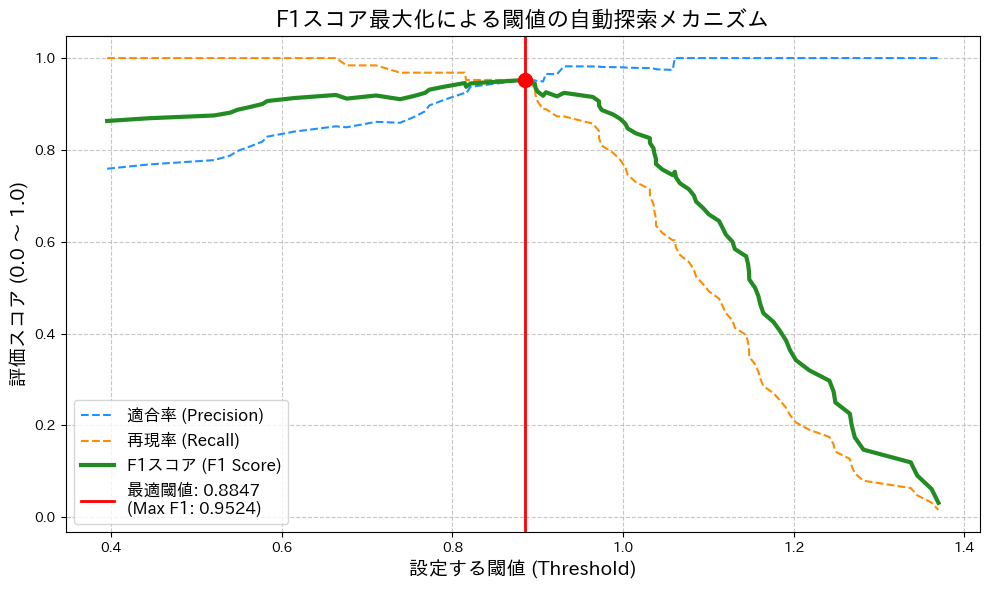


--- 定量評価結果 (VAE_FC) ---
設定閾値: 0.8847
正解率 (Accuracy)  : 91.57%
適合率 (Precision) : 95.16%
再現率 (Recall)    : 93.65%
F値 (F1-score)     : 94.40%



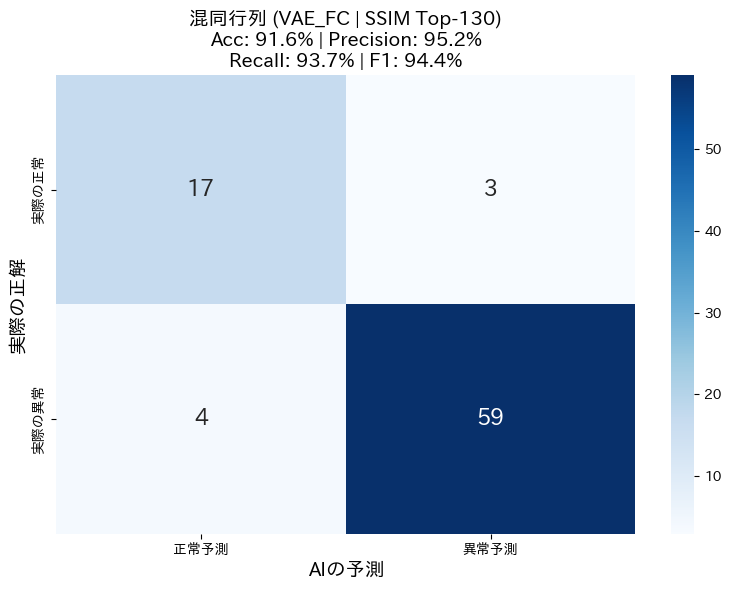

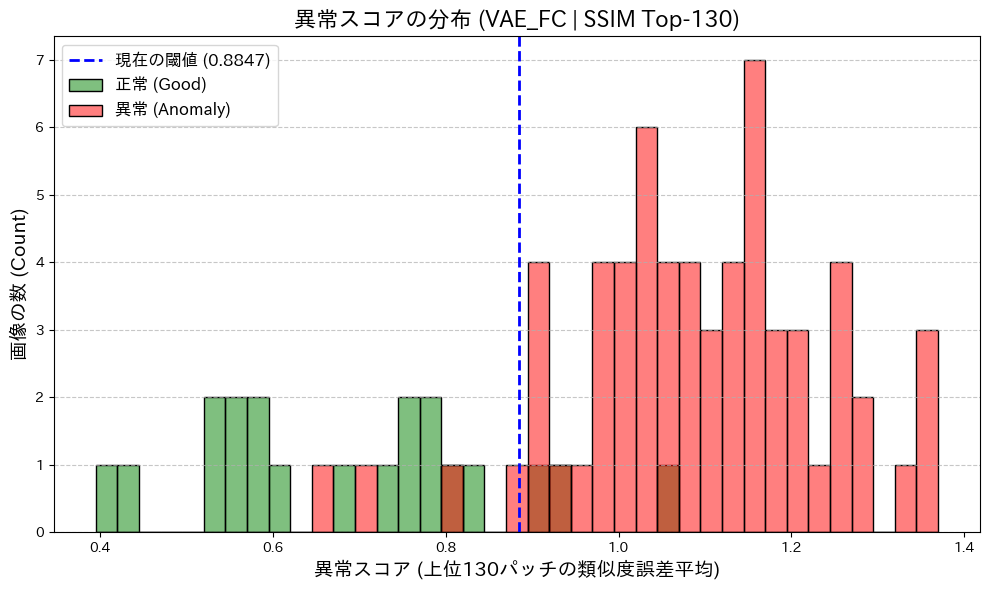


--- パターン別の代表例を可視化します ---

【1. TN: 正常を「正常」と正しく判断】 : 該当 17 件中 2 件を表示


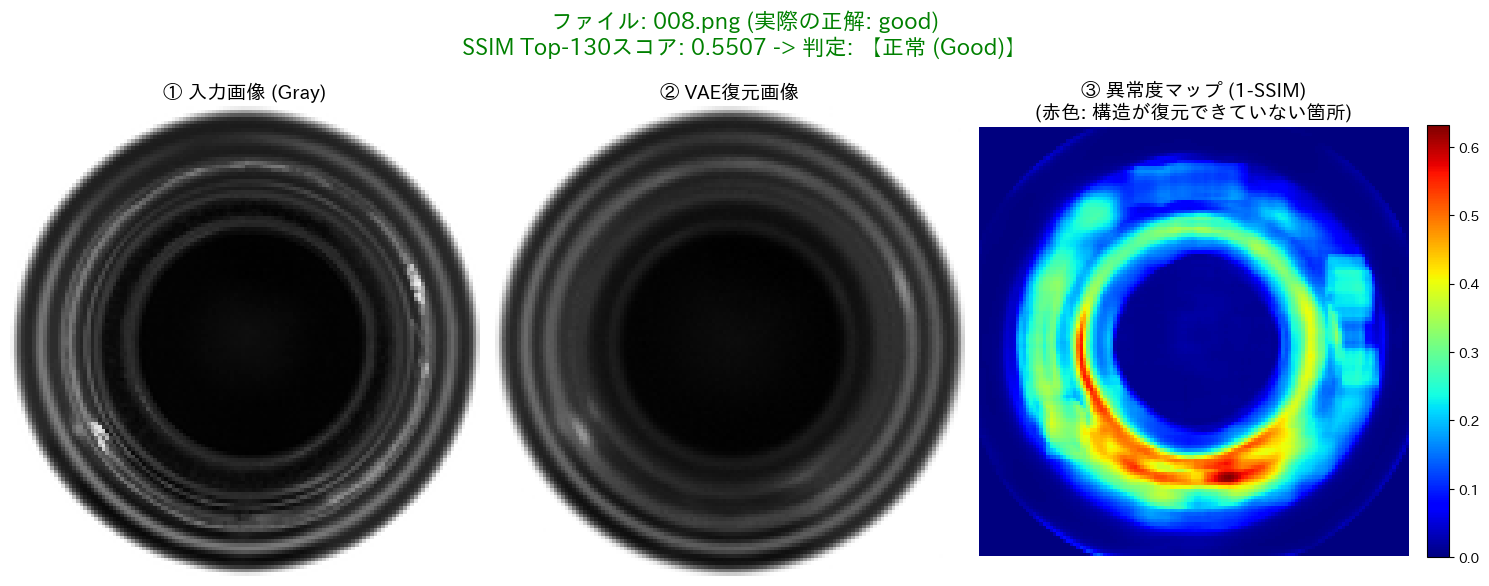

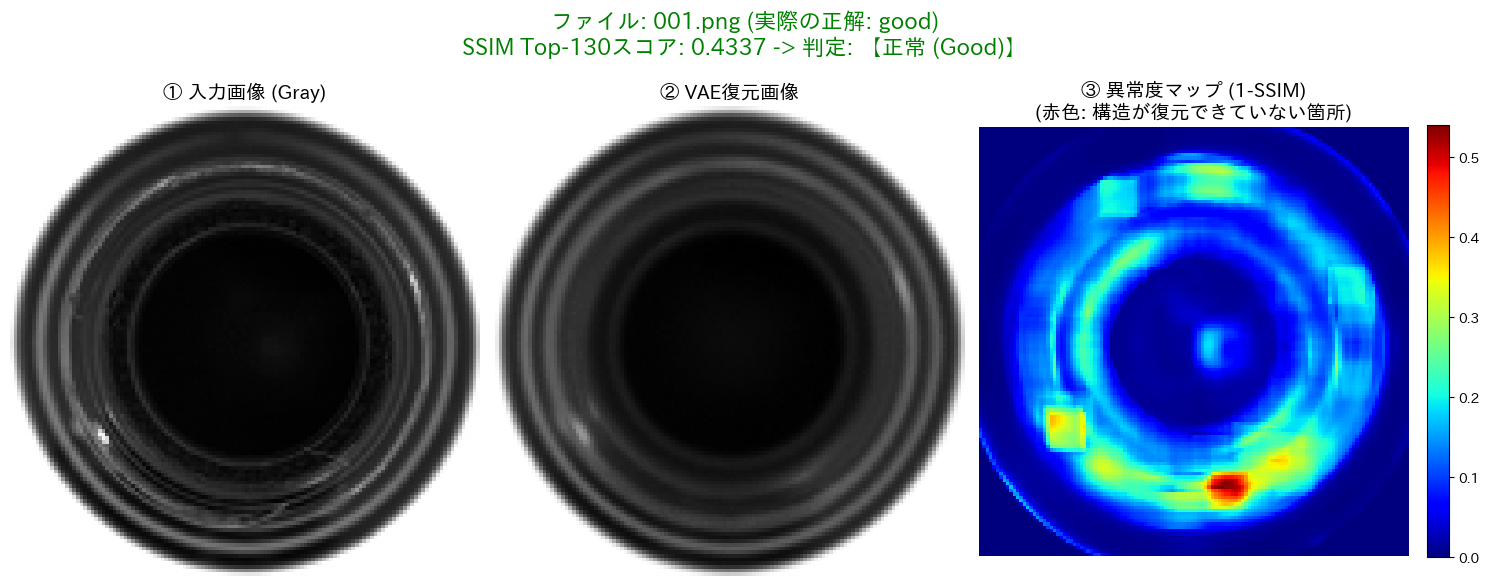


【2. FP: 正常を「異常」と誤って判断 (過剰検知)】 : 該当 3 件中 2 件を表示


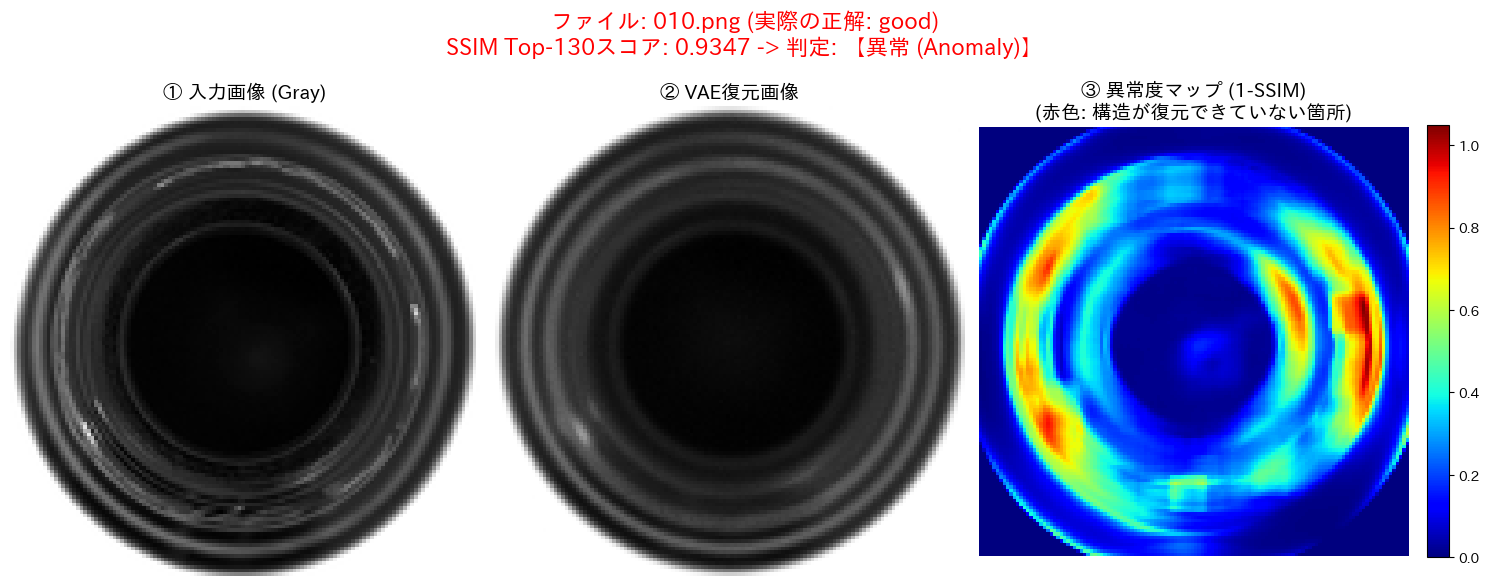

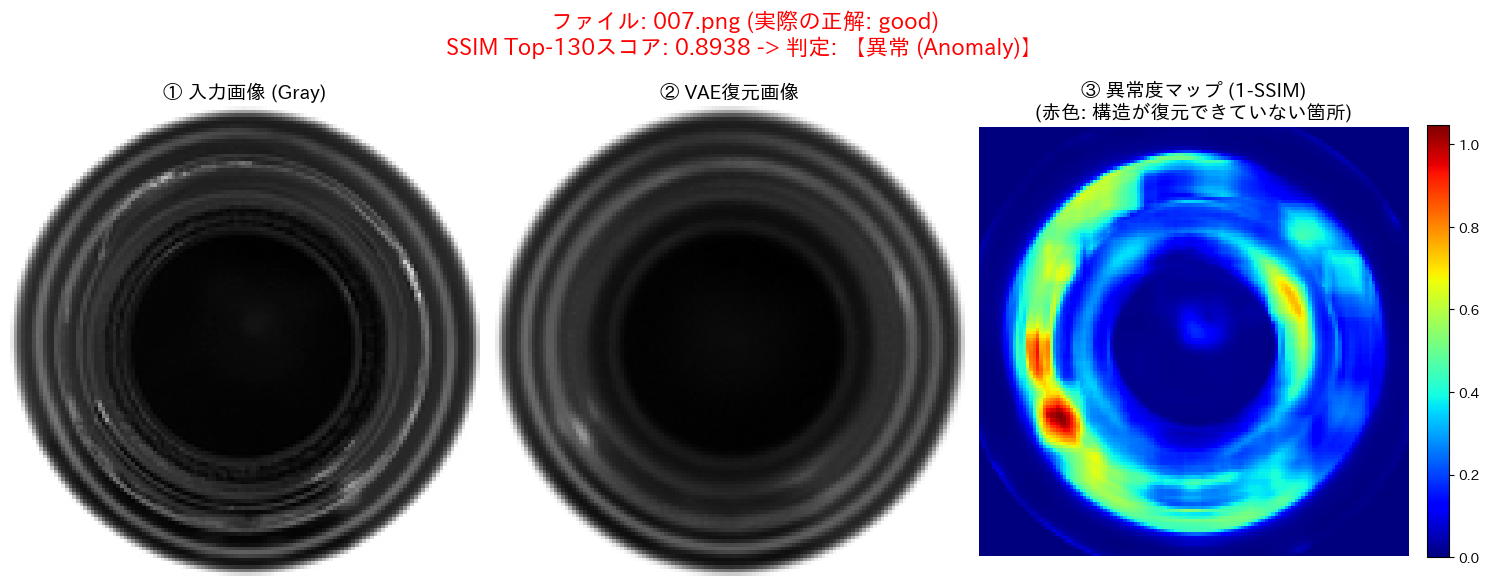


【3. FN: 異常を「正常」と誤って判断 (見逃し)】 : 該当 4 件中 2 件を表示


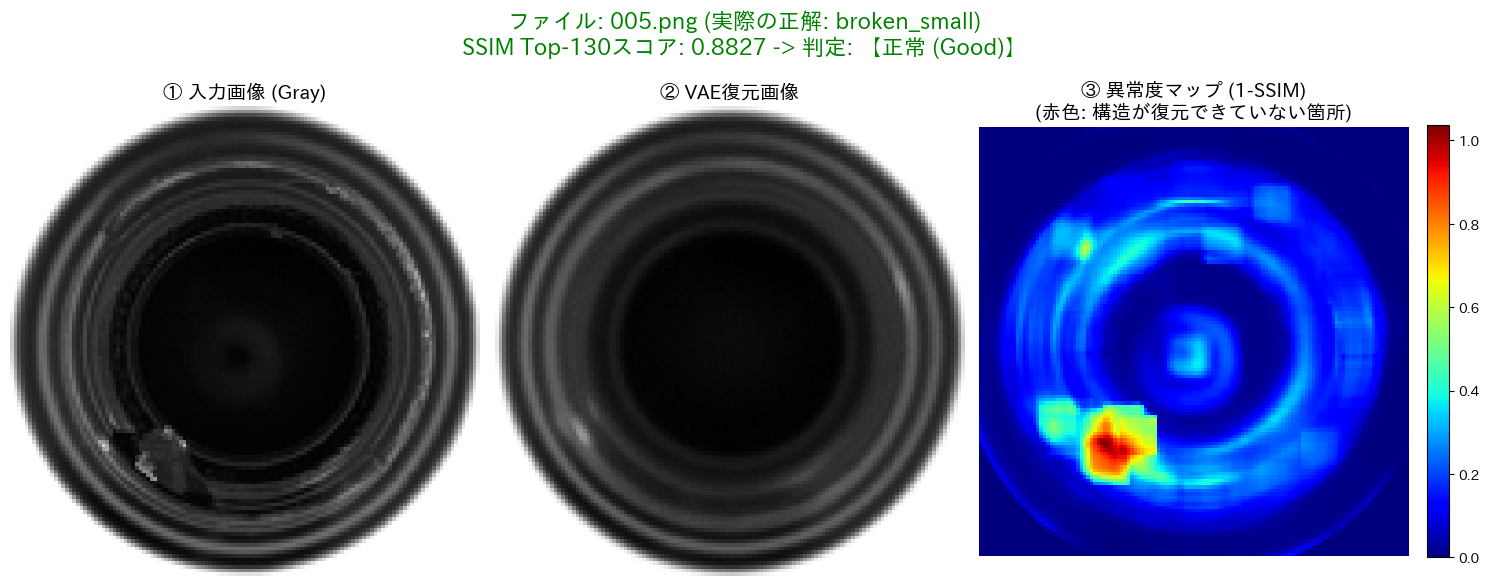

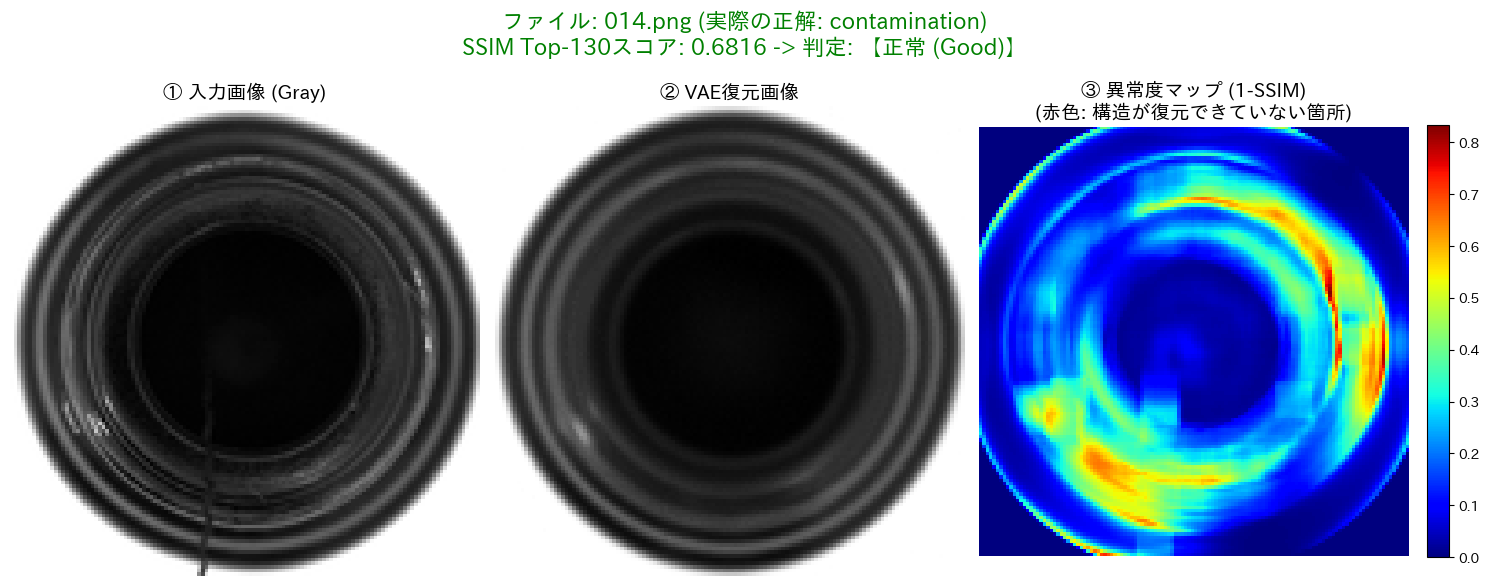


【4. TP: 異常を「異常」と正しく判断】 : 該当 59 件中 2 件を表示


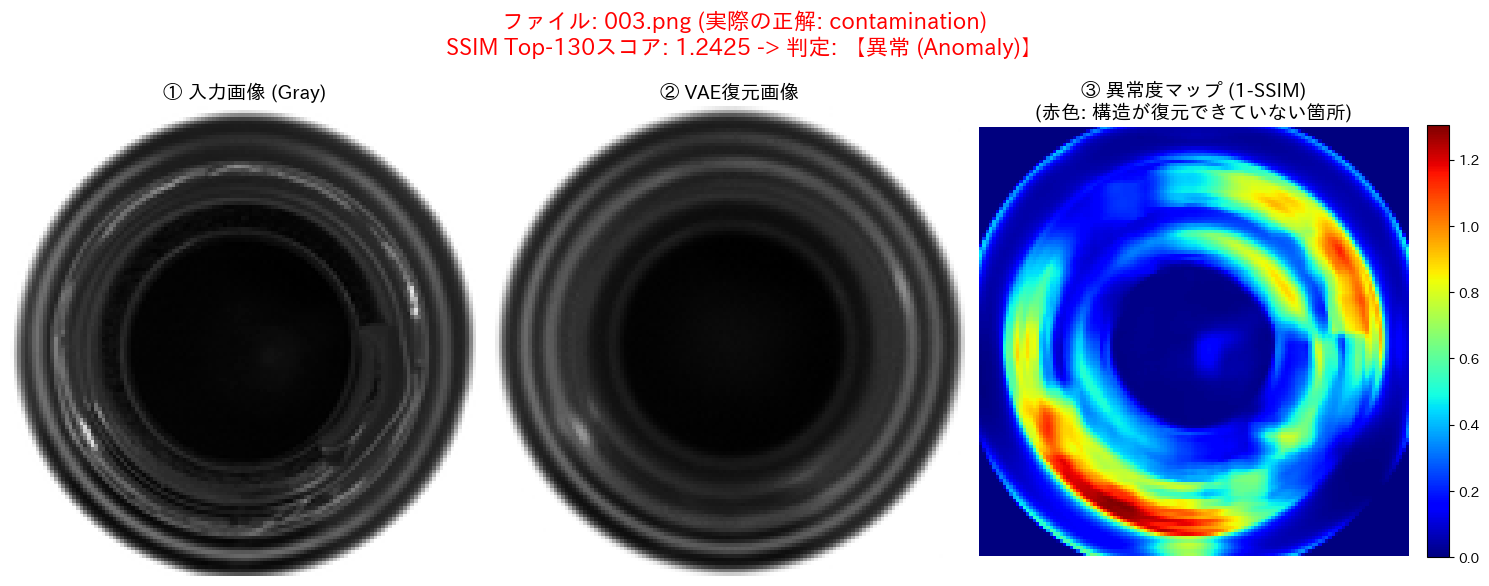

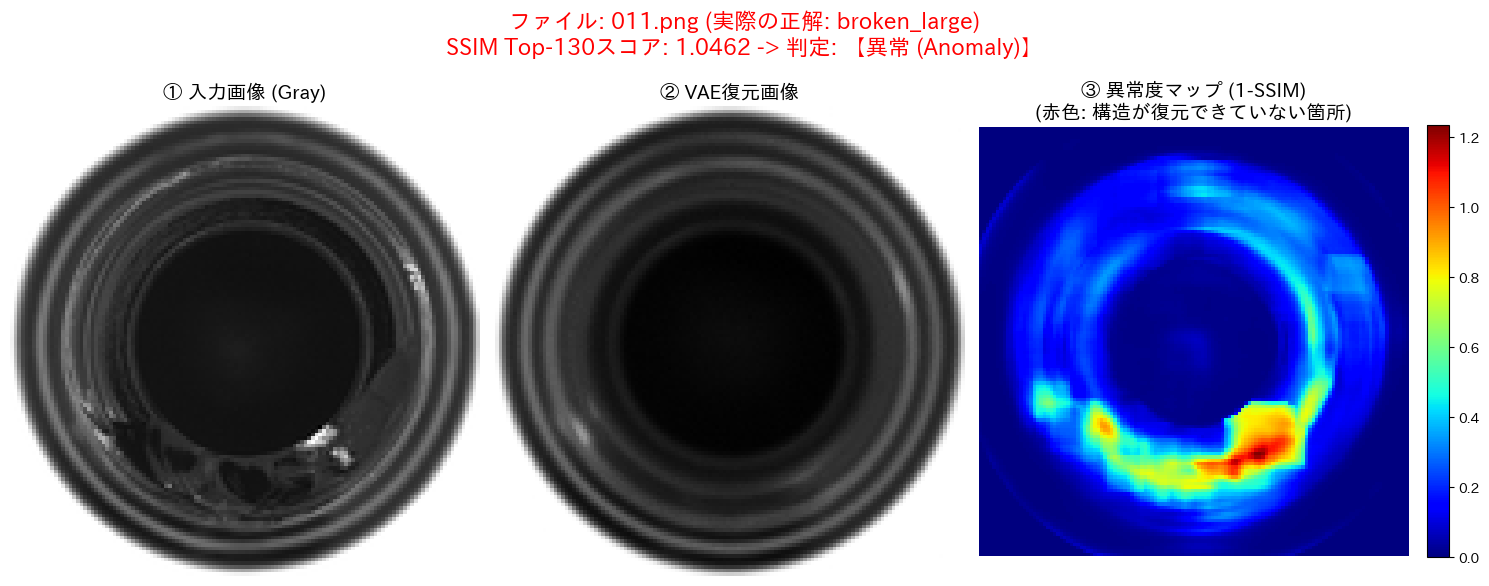


すべての検証プロセスが完了しました。


In [11]:
# =====================================================================
# 検証用スクリプト: 全結合層モデル（VAE_FC）専用
# ---------------------------------------------------------------------
# - 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# - 閾値設定: F1スコアを最大化する閾値の自動探索
# - 評価指標: AUROC, F1-score, Precision, Recall, Accuracy
# =====================================================================

import random
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score, 
    precision_score, f1_score, precision_recall_curve, roc_curve, auc
)

# 日本語フォントの文字化け対策
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義
# =====================================================================

# 学習時と同一の前処理パイプライン
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_FC(nn.Module):
    """
    全結合層(FC)のみを用いて特徴抽出と復元を行うベースラインモデル
    """
    def __init__(self, latent_dim=64):
        super(VAE_FC, self).__init__()
        
        # --- エンコーダ: 段階的に次元を圧縮 (16384 -> 1024 -> 256 -> 128) ---
        self.encoder = nn.Sequential(
            nn.Linear(16384, 1024), nn.ReLU(),
            nn.Linear(1024, 256), nn.ReLU(),
            nn.Linear(256, 128), nn.ReLU()
        )
        
        # 潜在空間へのマッピング
        self.fc_mu = nn.Linear(128, latent_dim)
        self.fc_logvar = nn.Linear(128, latent_dim)
        
        # --- デコーダ: 段階的に次元を復元 (64 -> 128 -> 256 -> 1024 -> 16384) ---
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 1024), nn.ReLU(),
            nn.Linear(1024, 16384), nn.Sigmoid()
        )

    def forward(self, x):
        # 画像を1次元に平坦化
        h = torch.flatten(x, start_dim=1)
        h = self.encoder(h)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        recon = self.decoder(z)
        
        # 画像の形状に戻して返す
        return recon.view(-1, 1, 128, 128), mu, logvar

# =====================================================================
# 2. 評価・解析・可視化用 関数群
# =====================================================================

def evaluate_dataset(model, test_dir, device, top_k=130):
    """データセット全体を推論し、正解ラベル、スコア、ファイルパスを収集する"""
    model.eval()
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\nデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: VAE_FC, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)

                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                # SSIMによる異常度マップの生成
                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                # 異常度上位Kパッチの平均をスコアとして採用
                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                y_true.append(true_label)
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    return np.array(y_true), np.array(scores), all_image_paths


def plot_roc_curve(y_true, scores, model_name="VAE Model"):
    """ROC曲線の描画とAUROCの計算を行う"""
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUROC = {roc_auc:.4f})')
    # plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUROC = 0.5)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (偽陽性率 / 過剰検知)', fontsize=14)
    plt.ylabel('True Positive Rate (真陽性率 / 再現率)', fontsize=14)
    plt.title(f'ROC Curve ({model_name})', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print(f"\n[{model_name}] AUROC: {roc_auc:.4f}")
    return roc_auc


def compute_optimal_threshold_f1(y_true, scores):
    """PR曲線からF1スコアが最大となる最適閾値を自動計算する"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    
    # ゼロ除算回避のため微小値 1e-10 を加算
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"\n[自動しきい値設定: F1スコア最大化]")
    print(f"-> 最適しきい値: {optimal_threshold:.4f} (Max F1: {f1_scores[optimal_idx]:.4f})")
    
    return optimal_threshold


def plot_f1_optimization(y_true, scores):
    """閾値の変化に対する各種スコアの推移と、最適閾値のポイントを可視化する"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    max_f1 = f1_scores[optimal_idx]

    plt.figure(figsize=(10, 6))
    
    plt.plot(thresholds, precisions[:-1], label='適合率 (Precision)', color='dodgerblue', linestyle='--')
    plt.plot(thresholds, recalls[:-1], label='再現率 (Recall)', color='darkorange', linestyle='--')
    plt.plot(thresholds, f1_scores[:-1], label='F1スコア (F1 Score)', color='forestgreen', linewidth=3)
    
    plt.axvline(x=optimal_threshold, color='red', linestyle='-', linewidth=2, 
                label=f'最適閾値: {optimal_threshold:.4f}\n(Max F1: {max_f1:.4f})')
    plt.scatter(optimal_threshold, max_f1, color='red', s=100, zorder=5) 

    plt.title('F1スコア最大化による閾値の自動探索メカニズム', fontsize=16, fontweight='bold')
    plt.xlabel('設定する閾値 (Threshold)', fontsize=14)
    plt.ylabel('評価スコア (0.0 〜 1.0)', fontsize=14)
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    """混同行列と定量評価指標(正解率・適合率・再現率・F値)を描画する"""
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (VAE_FC) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    title_str = (f"混同行列 (VAE_FC | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_score_distribution(y_true, scores, threshold, top_k=130):
    """正常画像と異常画像の異常スコア分布(ヒストグラム)を描画する"""
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold:.4f})')

    plt.title(f"異常スコアの分布 (VAE_FC | SSIM Top-{top_k})", fontsize=16, fontweight='bold')
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    """1枚の画像を推論し、入力・復元・異常度マップの3パネルで可視化する"""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# =====================================================================
# 3. 実行ブロック
# =====================================================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    # --- モデルのインスタンス化と重みのロード ---
    model = VAE_FC(latent_dim=64).to(device)
    MODEL_PATH = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\saved_models\vae_FC_Only_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"VAE_FC の重みを読み込みました。\n")

    # --- テスト設定 ---
    TEST_DIR = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\data\bottle\test"
    TOP_K = 130

    # --- 検証プロセスの実行 ---

    # 1. 全画像の異常スコアを算出
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. AUROCの計算と描画（閾値非依存の性能評価）
    auroc_score = plot_roc_curve(y_true, scores, model_name="VAE_FC_Only")

    # 3. F1スコアが最大となる最適閾値を探索
    THRESHOLD = compute_optimal_threshold_f1(y_true, scores)

    # 4. F1最適化の推移を図解
    plot_f1_optimization(y_true, scores)

    # 5. 決定した閾値に基づく最終的な予測ラベルを作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 6. 定量評価・スコア分布の描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)

    # --- 各判定パターン（TP/FP/TN/FN）ごとの画像確認 ---
    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")

使用デバイス: cpu
VAE_CNN_Shallow3 の重みを読み込みました。

テストデータ全件の評価を開始します... (モデル: VAE_CNN_Shallow3, Top-K: 130)
評価が完了しました。


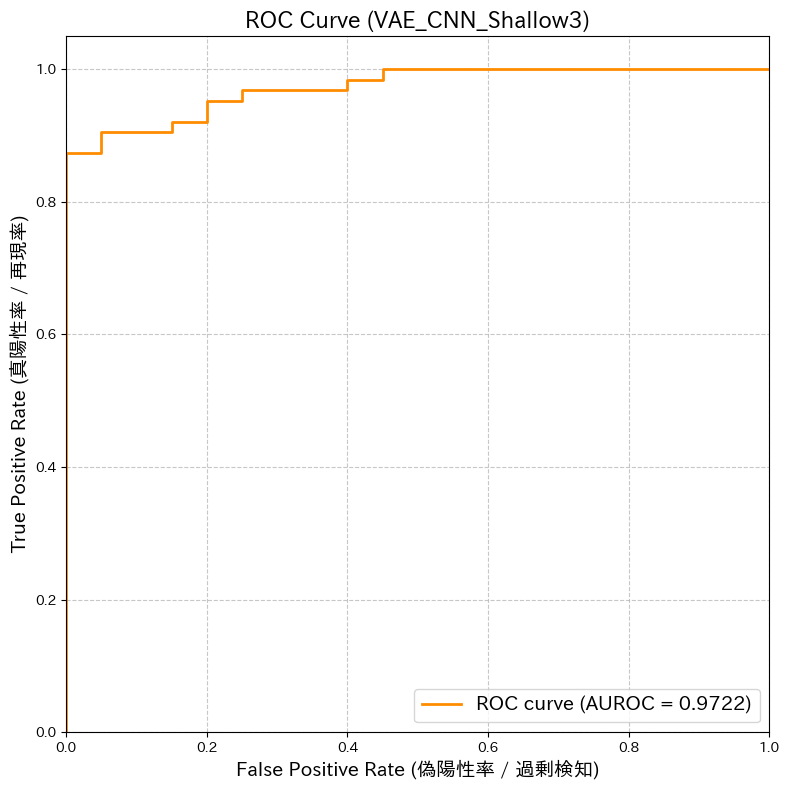


[VAE_CNN_Shallow3] AUROC: 0.9722

[自動しきい値設定: F1スコア最大化]
-> 最適しきい値: 0.7934 (Max F1: 0.9457)


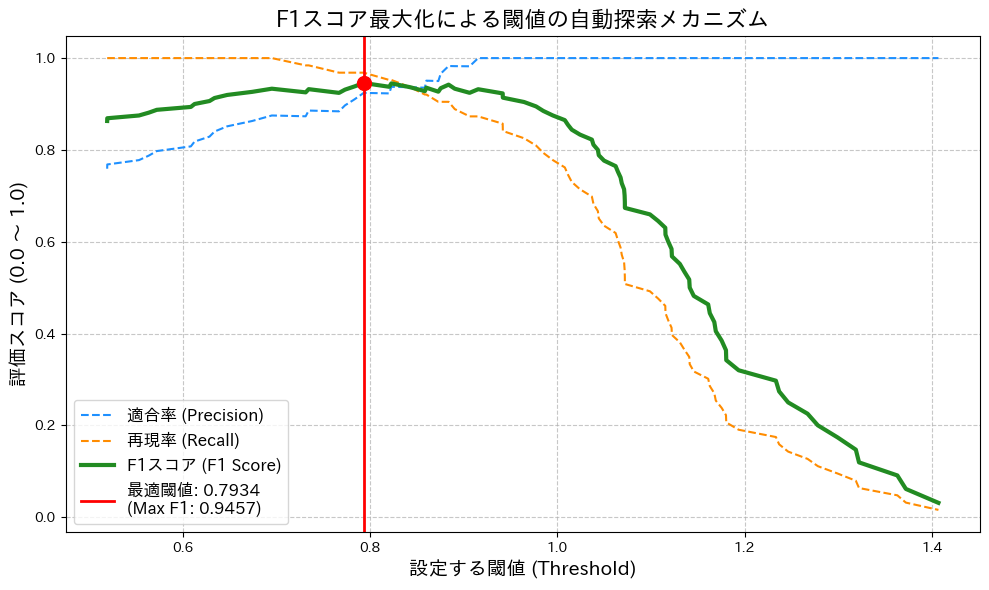


--- 定量評価結果 (VAE_CNN_Shallow3) ---
設定閾値: 0.7934
正解率 (Accuracy)  : 90.36%
適合率 (Precision) : 92.31%
再現率 (Recall)    : 95.24%
F値 (F1-score)     : 93.75%



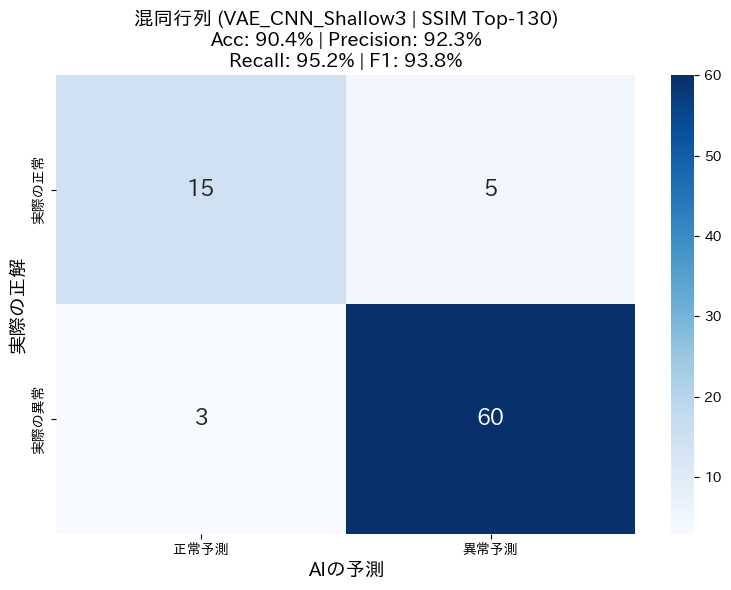

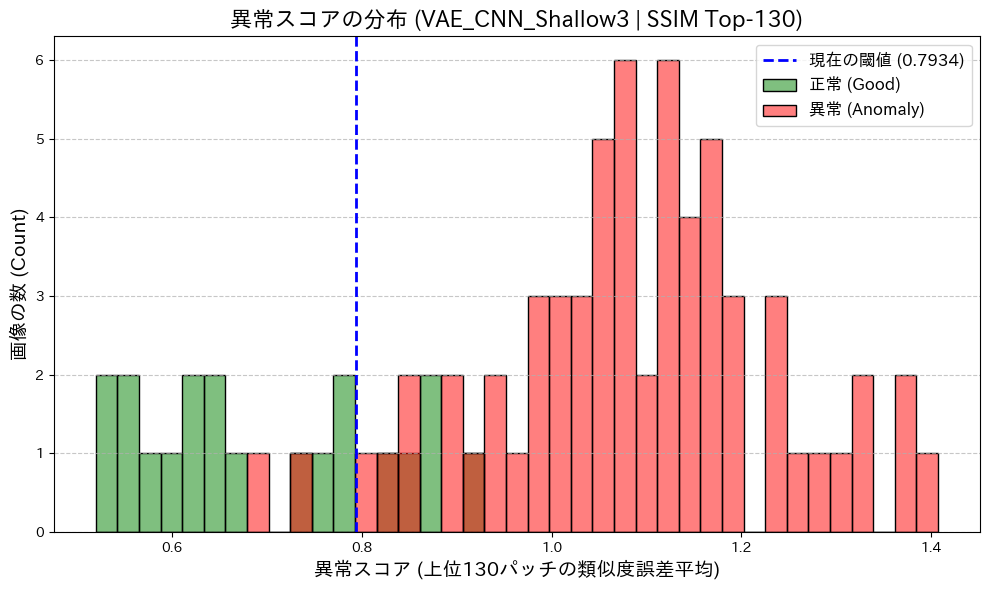


--- パターン別の代表例を可視化します ---

【1. TN: 正常を「正常」と正しく判断】 : 該当 15 件中 2 件を表示


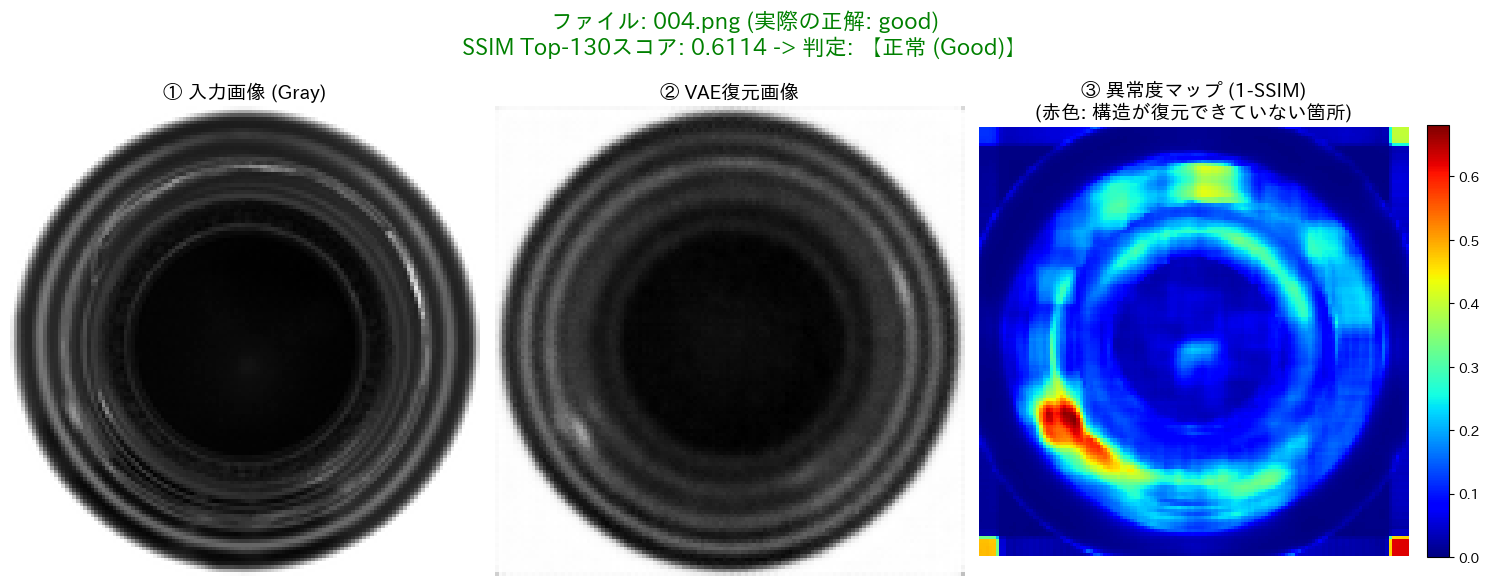

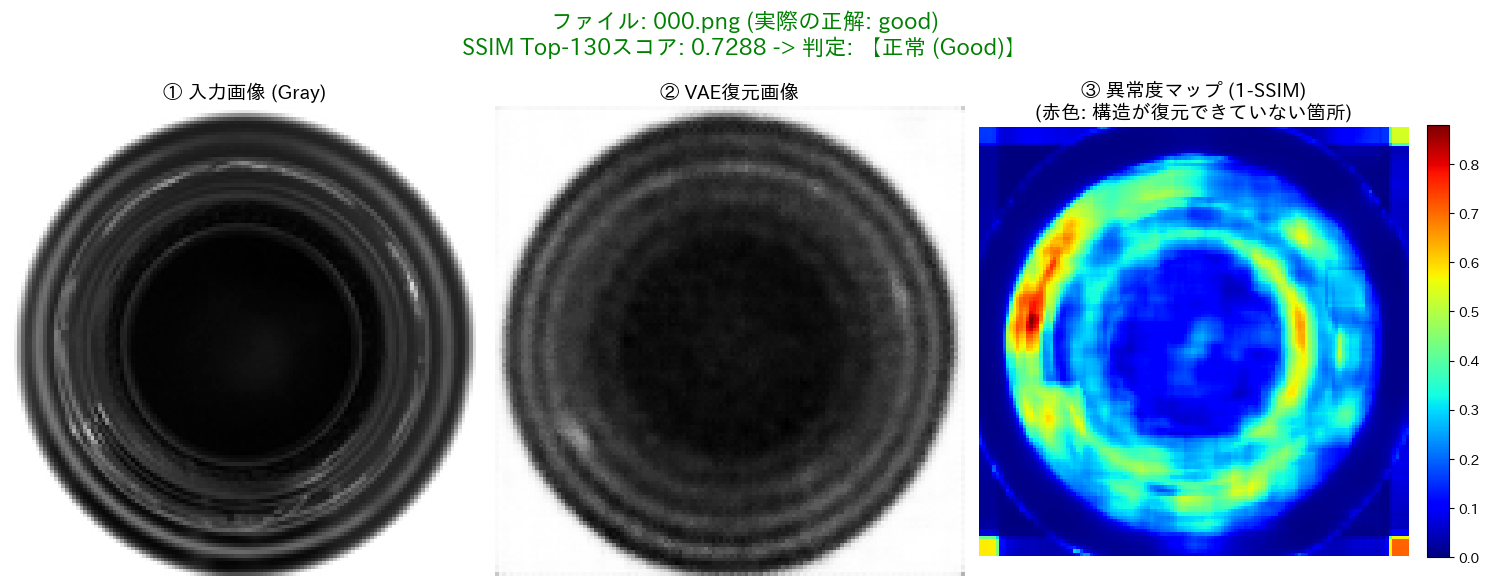


【2. FP: 正常を「異常」と誤って判断 (過剰検知)】 : 該当 5 件中 2 件を表示


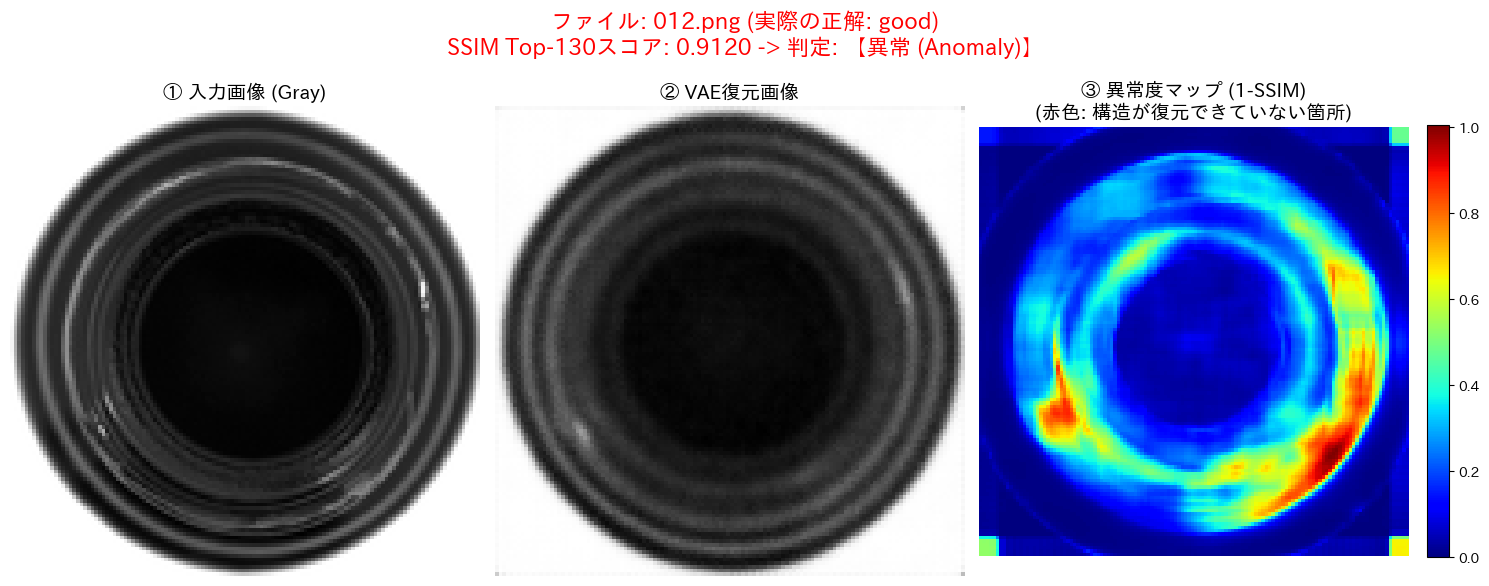

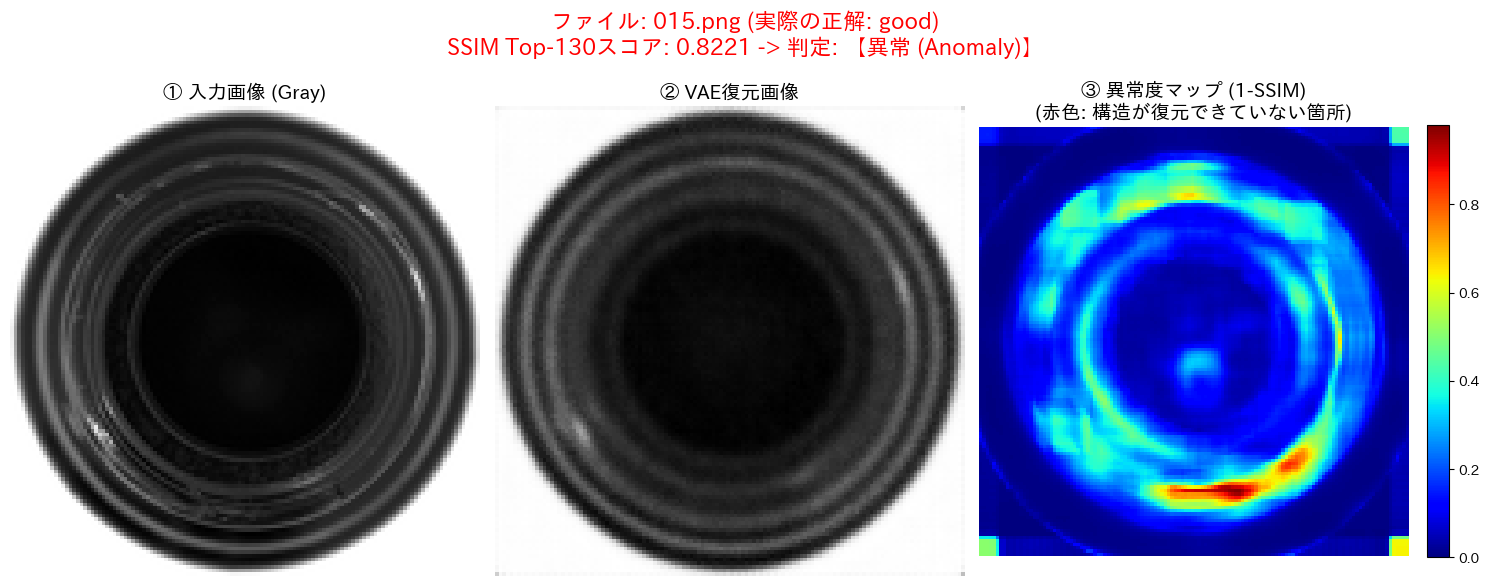


【3. FN: 異常を「正常」と誤って判断 (見逃し)】 : 該当 3 件中 2 件を表示


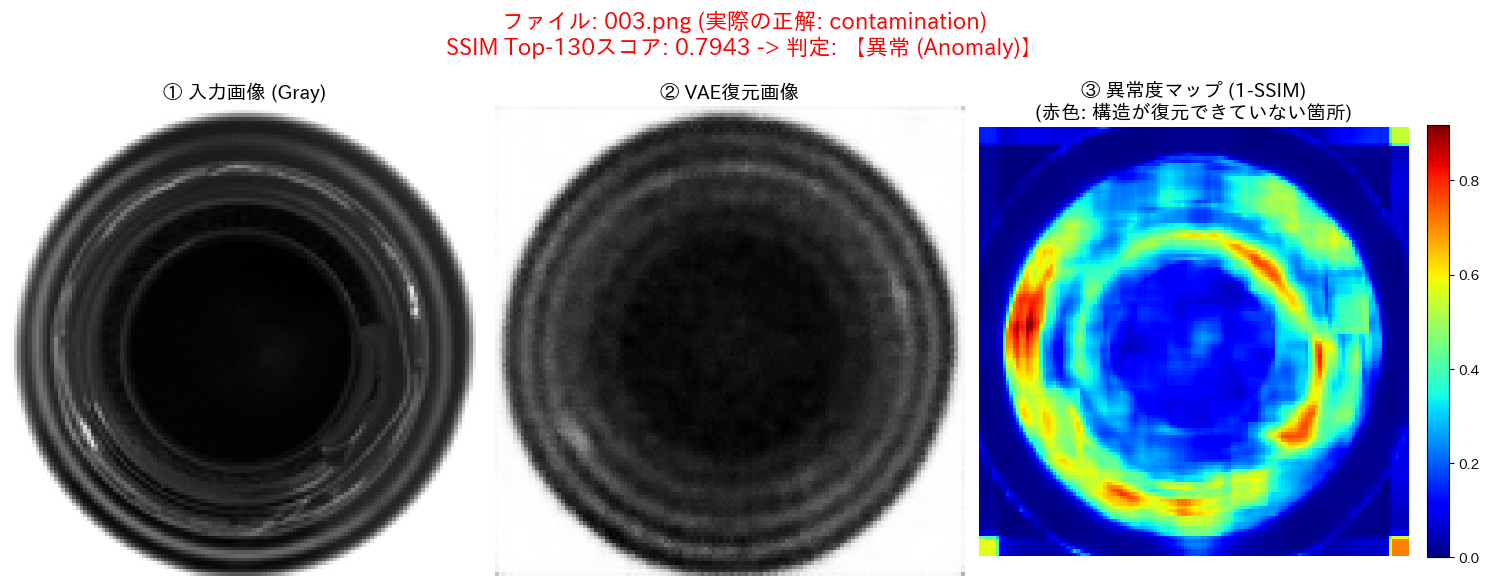

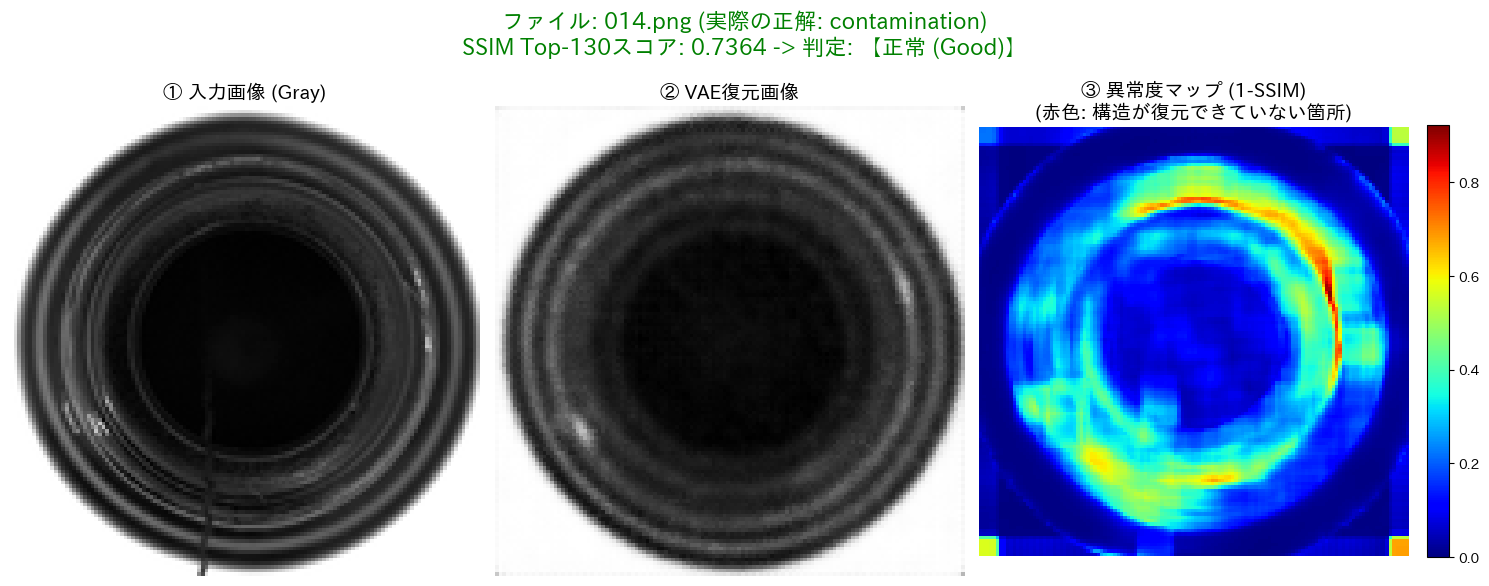


【4. TP: 異常を「異常」と正しく判断】 : 該当 60 件中 2 件を表示


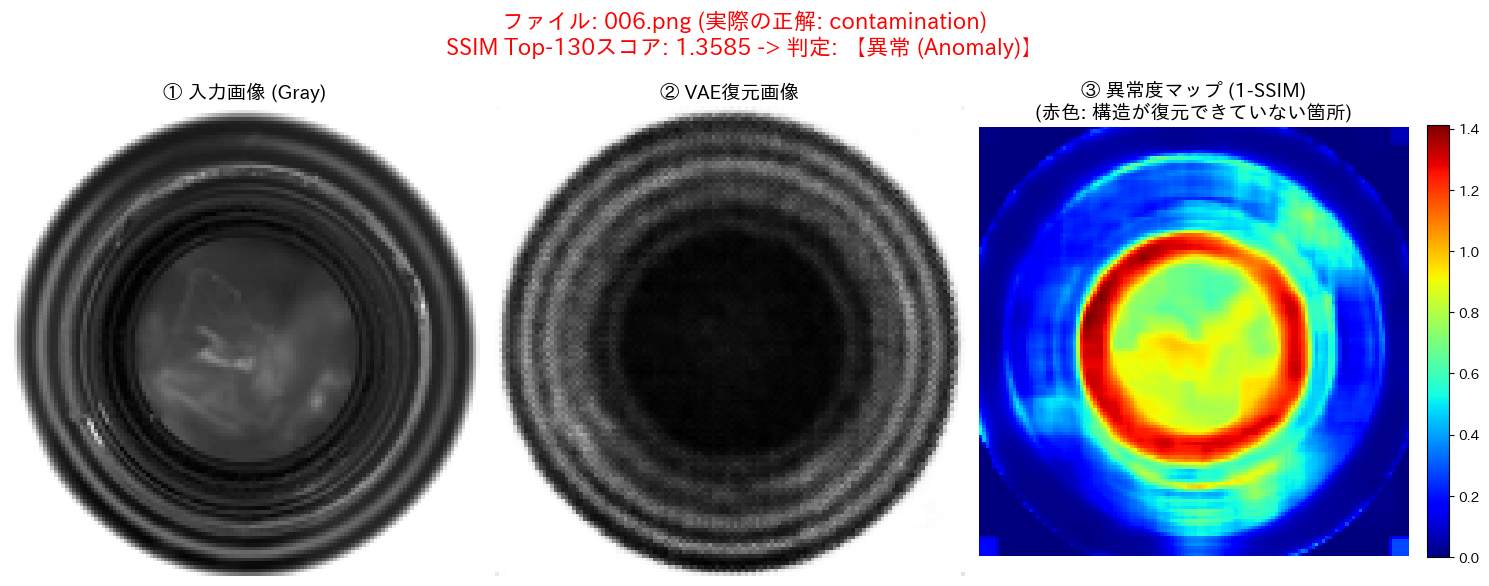

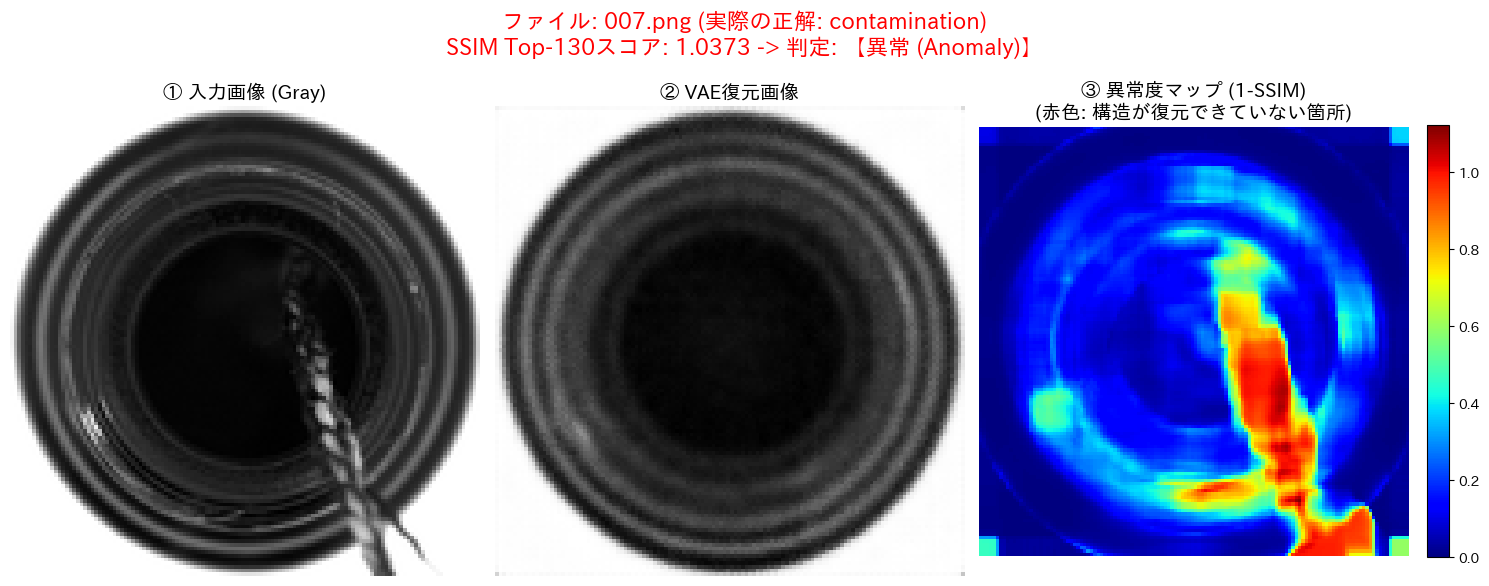


すべての検証プロセスが完了しました。


In [12]:
# =====================================================================
# 検証用スクリプト: 浅いCNNモデル（VAE_CNN_Shallow3）専用
# ---------------------------------------------------------------------
# - 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# - 閾値設定: F1スコアを最大化する閾値の自動探索
# - 評価指標: AUROC, F1-score, Precision, Recall, Accuracy
# =====================================================================

import random
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score, 
    precision_score, f1_score, precision_recall_curve, roc_curve, auc
)

# 日本語フォントの文字化け対策
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義
# =====================================================================

# 学習時と同一の前処理パイプライン
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_CNN_Shallow3(nn.Module):
    """
    浅い3層の畳み込み層を用いた軽量VAEモデル
    """
    def __init__(self, latent_dim=64):
        super(VAE_CNN_Shallow3, self).__init__()
        
        # --- エンコーダ: 畳み込み層で空間情報を保ちながら圧縮 (128 -> 64 -> 32 -> 16) ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU()
        )
        
        # 64チャンネル * 16 * 16 = 16384次元
        self.fc_mu = nn.Linear(64 * 16 * 16, latent_dim)
        self.fc_logvar = nn.Linear(64 * 16 * 16, latent_dim)
        
        self.decoder_fc = nn.Linear(latent_dim, 64 * 16 * 16)
        
        # --- デコーダ: 逆畳み込み層で元の画像サイズへ復元 ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        # 潜在変数の発散(KLD爆発)を防ぐ安全装置
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 64, 16, 16) 
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価・解析・可視化用 関数群
# =====================================================================

def evaluate_dataset(model, test_dir, device, top_k=130):
    """データセット全体を推論し、正解ラベル、スコア、ファイルパスを収集する"""
    model.eval()
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\nデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: VAE_CNN_Shallow3, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)

                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                # SSIMによる異常度マップの生成
                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                # 異常度上位Kパッチの平均をスコアとして採用
                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                y_true.append(true_label)
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    return np.array(y_true), np.array(scores), all_image_paths


def plot_roc_curve(y_true, scores, model_name="VAE Model"):
    """ROC曲線の描画とAUROCの計算を行う"""
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUROC = {roc_auc:.4f})')
    # plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUROC = 0.5)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (偽陽性率 / 過剰検知)', fontsize=14)
    plt.ylabel('True Positive Rate (真陽性率 / 再現率)', fontsize=14)
    plt.title(f'ROC Curve ({model_name})', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print(f"\n[{model_name}] AUROC: {roc_auc:.4f}")
    return roc_auc


def compute_optimal_threshold_f1(y_true, scores):
    """PR曲線からF1スコアが最大となる最適閾値を自動計算する"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    
    # ゼロ除算回避のため微小値 1e-10 を加算
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"\n[自動しきい値設定: F1スコア最大化]")
    print(f"-> 最適しきい値: {optimal_threshold:.4f} (Max F1: {f1_scores[optimal_idx]:.4f})")
    
    return optimal_threshold


def plot_f1_optimization(y_true, scores):
    """閾値の変化に対する各種スコアの推移と、最適閾値のポイントを可視化する"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    max_f1 = f1_scores[optimal_idx]

    plt.figure(figsize=(10, 6))
    
    plt.plot(thresholds, precisions[:-1], label='適合率 (Precision)', color='dodgerblue', linestyle='--')
    plt.plot(thresholds, recalls[:-1], label='再現率 (Recall)', color='darkorange', linestyle='--')
    plt.plot(thresholds, f1_scores[:-1], label='F1スコア (F1 Score)', color='forestgreen', linewidth=3)
    
    plt.axvline(x=optimal_threshold, color='red', linestyle='-', linewidth=2, 
                label=f'最適閾値: {optimal_threshold:.4f}\n(Max F1: {max_f1:.4f})')
    plt.scatter(optimal_threshold, max_f1, color='red', s=100, zorder=5) 

    plt.title('F1スコア最大化による閾値の自動探索メカニズム', fontsize=16, fontweight='bold')
    plt.xlabel('設定する閾値 (Threshold)', fontsize=14)
    plt.ylabel('評価スコア (0.0 〜 1.0)', fontsize=14)
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    """混同行列と定量評価指標(正解率・適合率・再現率・F値)を描画する"""
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (VAE_CNN_Shallow3) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    title_str = (f"混同行列 (VAE_CNN_Shallow3 | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_score_distribution(y_true, scores, threshold, top_k=130):
    """正常画像と異常画像の異常スコア分布(ヒストグラム)を描画する"""
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold:.4f})')

    plt.title(f"異常スコアの分布 (VAE_CNN_Shallow3 | SSIM Top-{top_k})", fontsize=16, fontweight='bold')
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    """1枚の画像を推論し、入力・復元・異常度マップの3パネルで可視化する"""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# =====================================================================
# 3. 実行ブロック
# =====================================================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    # --- モデルのインスタンス化と重みのロード ---
    model = VAE_CNN_Shallow3(latent_dim=64).to(device)
    
    # ★ 実際の浅いCNNモデルの重みファイル名に合わせて変更してください
    MODEL_PATH = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\saved_models\vae_CNN_Shallow3_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"VAE_CNN_Shallow3 の重みを読み込みました。\n")

    # --- テスト設定 ---
    TEST_DIR = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\data\bottle\test"
    TOP_K = 130

    # --- 検証プロセスの実行 ---

    # 1. 全画像の異常スコアを算出
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. AUROCの計算と描画（閾値非依存の性能評価）
    auroc_score = plot_roc_curve(y_true, scores, model_name="VAE_CNN_Shallow3")

    # 3. F1スコアが最大となる最適閾値を探索
    THRESHOLD = compute_optimal_threshold_f1(y_true, scores)
    
    # 4. F1最適化の推移を図解
    plot_f1_optimization(y_true, scores)

    # 5. 決定した閾値に基づく最終的な予測ラベルを作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 6. 定量評価・スコア分布の描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)

    # --- 各判定パターン（TP/FP/TN/FN）ごとの画像確認 ---
    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")

使用デバイス: cpu
VAE_CNN_Deep5 の重みを読み込みました。

テストデータ全件の評価を開始します... (モデル: VAE_CNN_Deep5, Top-K: 130)
評価が完了しました。


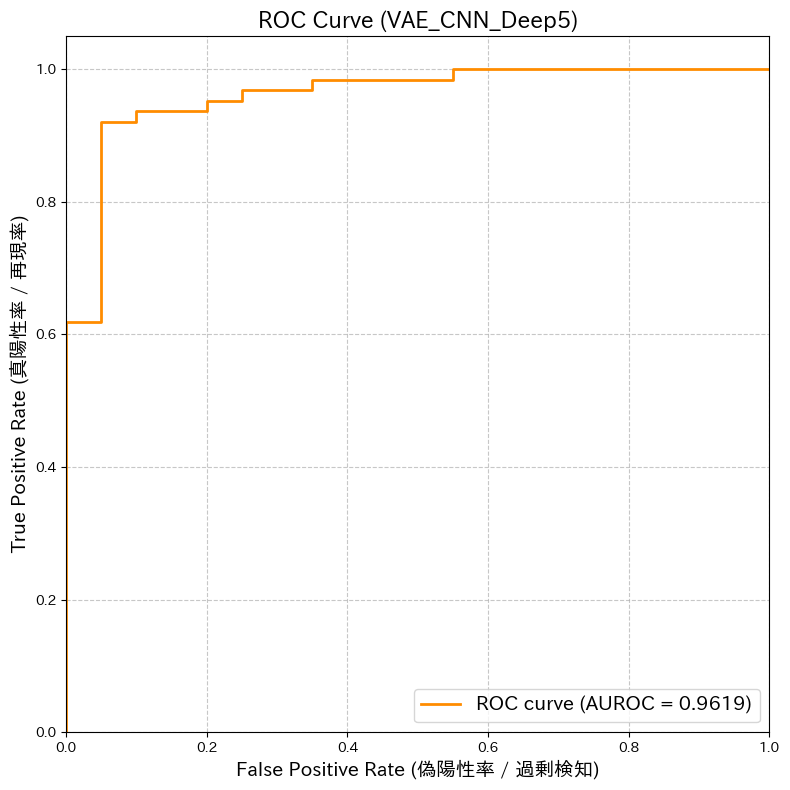


[VAE_CNN_Deep5] AUROC: 0.9619

[自動しきい値設定: F1スコア最大化]
-> 最適しきい値: 0.9183 (Max F1: 0.9516)


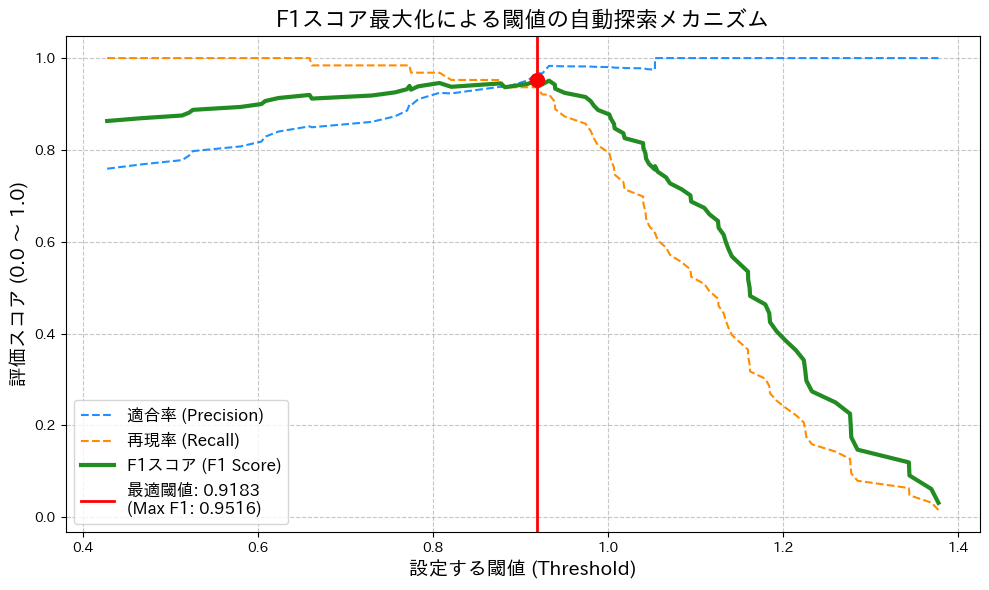


--- 定量評価結果 (VAE_CNN_Deep5) ---
設定閾値: 0.9183
正解率 (Accuracy)  : 91.57%
適合率 (Precision) : 96.67%
再現率 (Recall)    : 92.06%
F値 (F1-score)     : 94.31%



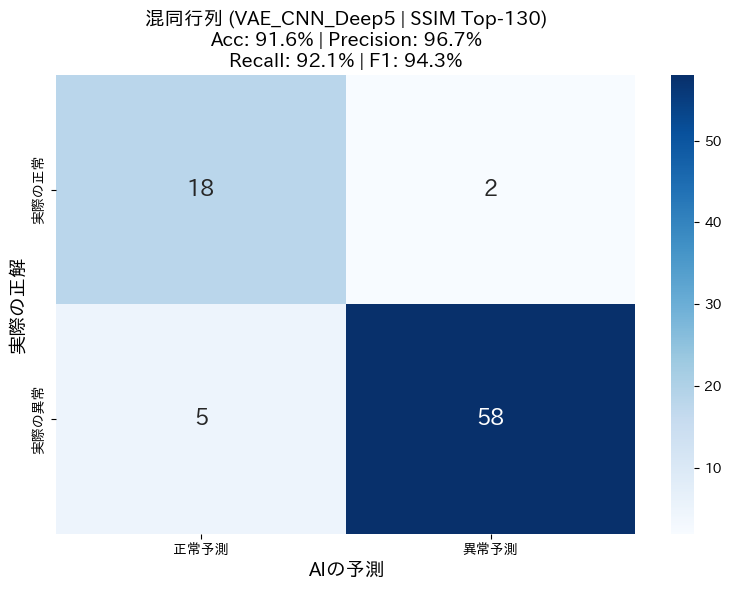

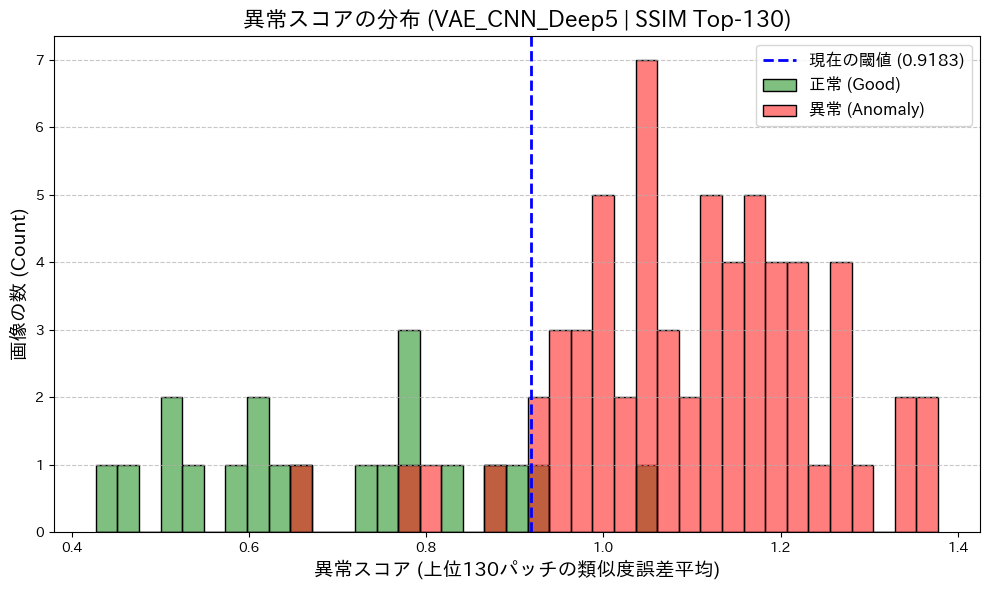


--- パターン別の代表例を可視化します ---

【1. TN: 正常を「正常」と正しく判断】 : 該当 18 件中 2 件を表示


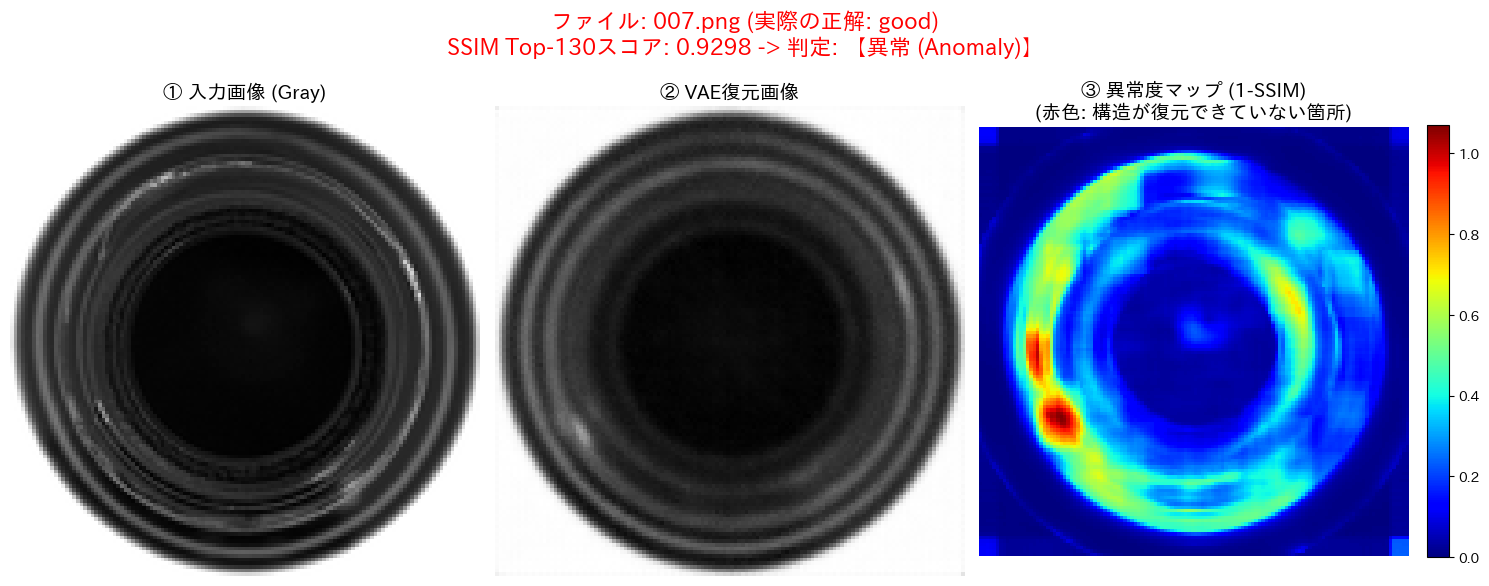

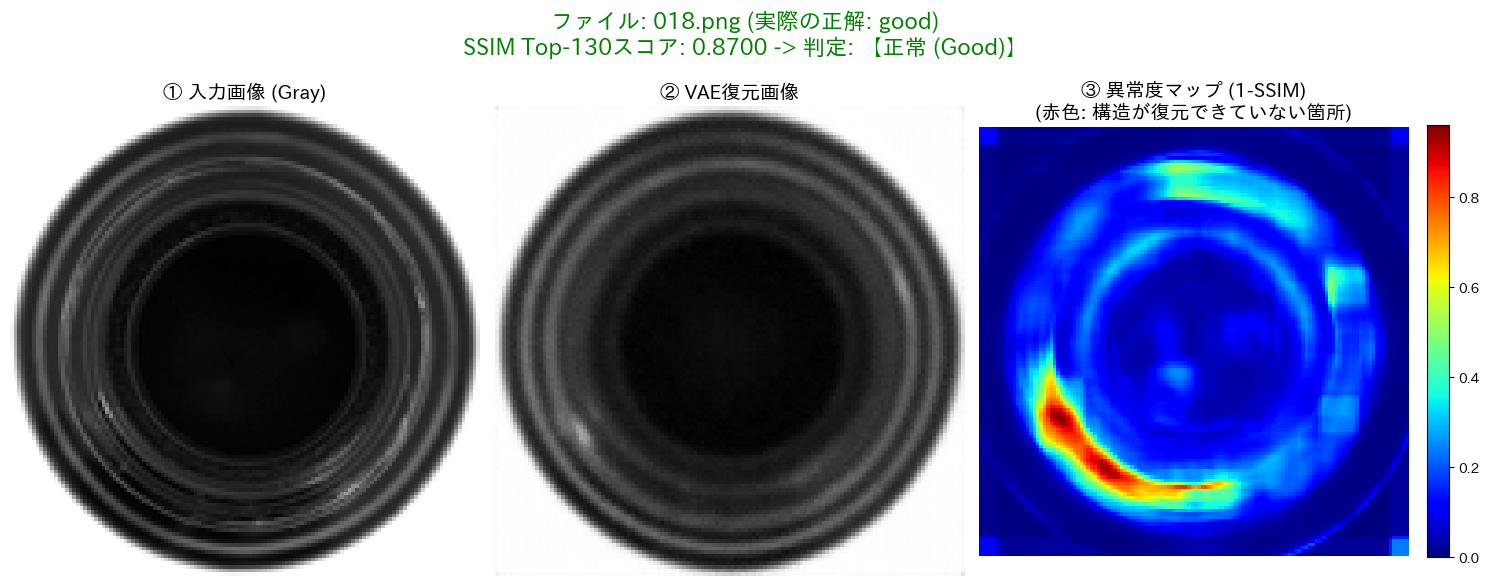


【2. FP: 正常を「異常」と誤って判断 (過剰検知)】 : 該当 2 件中 2 件を表示


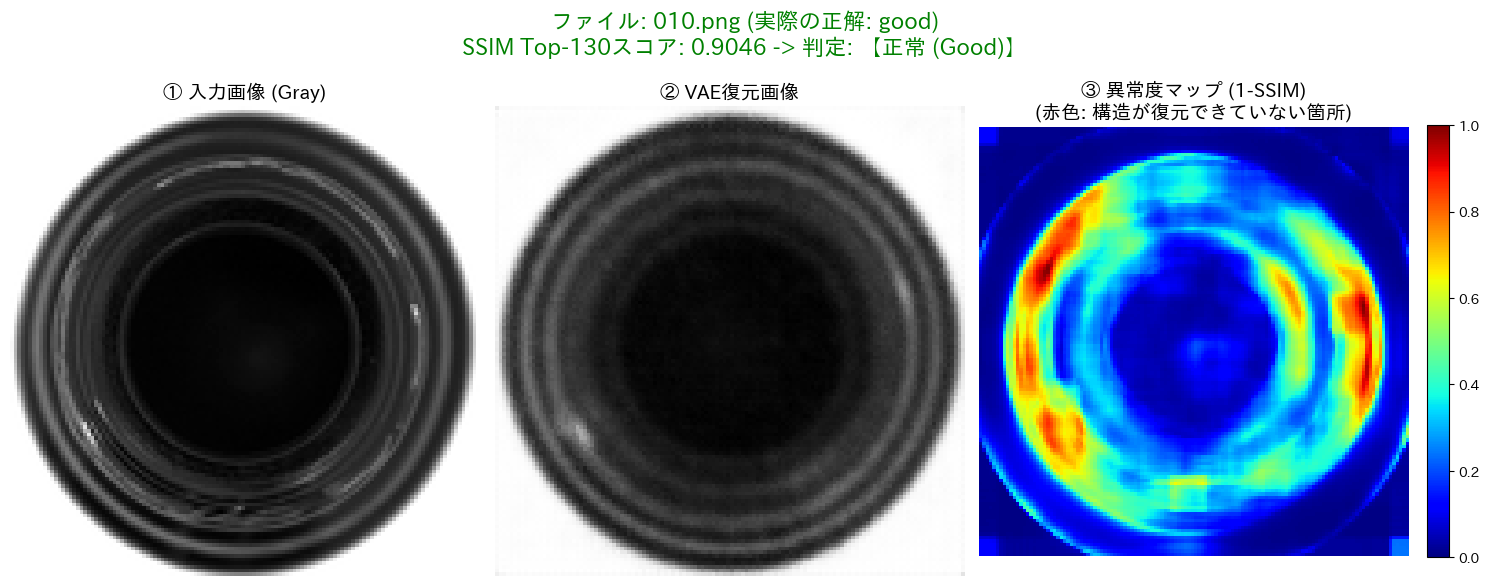

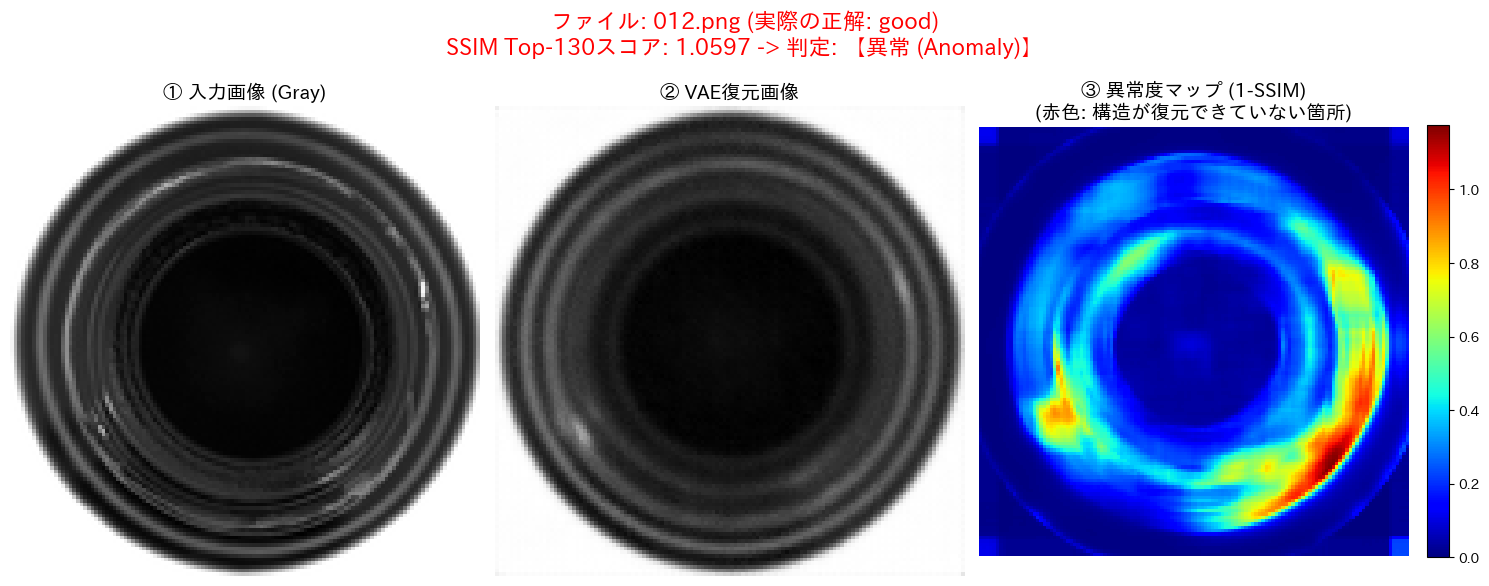


【3. FN: 異常を「正常」と誤って判断 (見逃し)】 : 該当 5 件中 2 件を表示


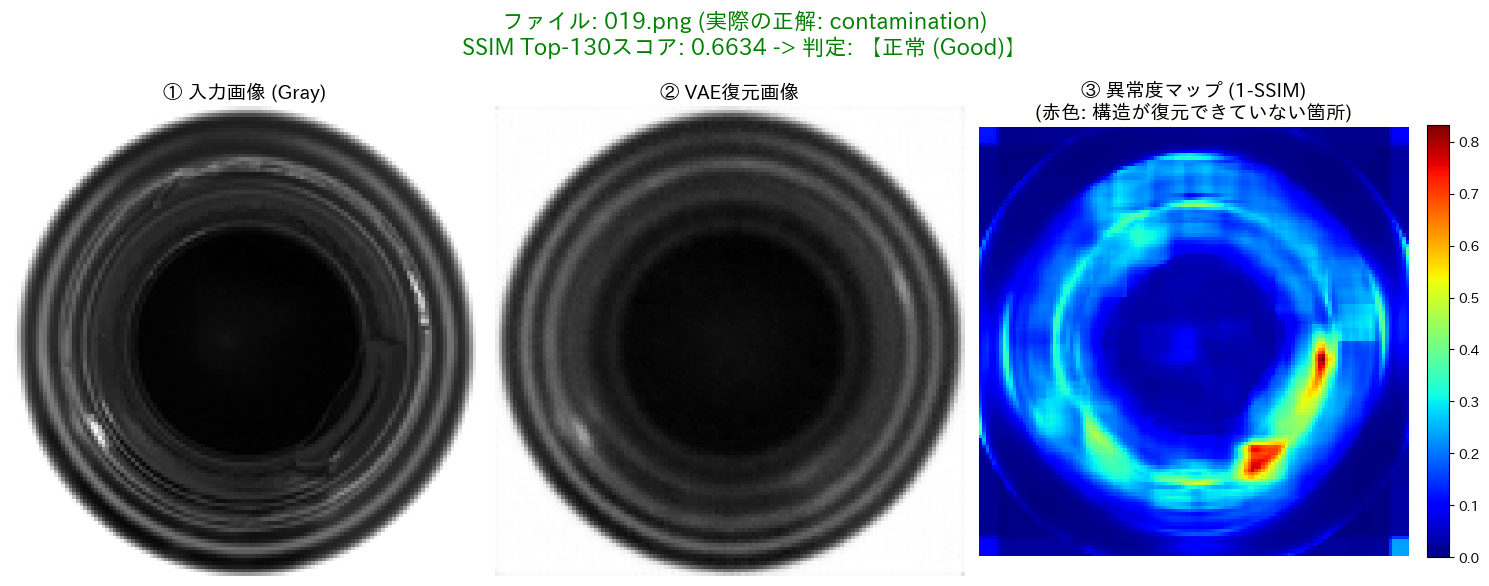

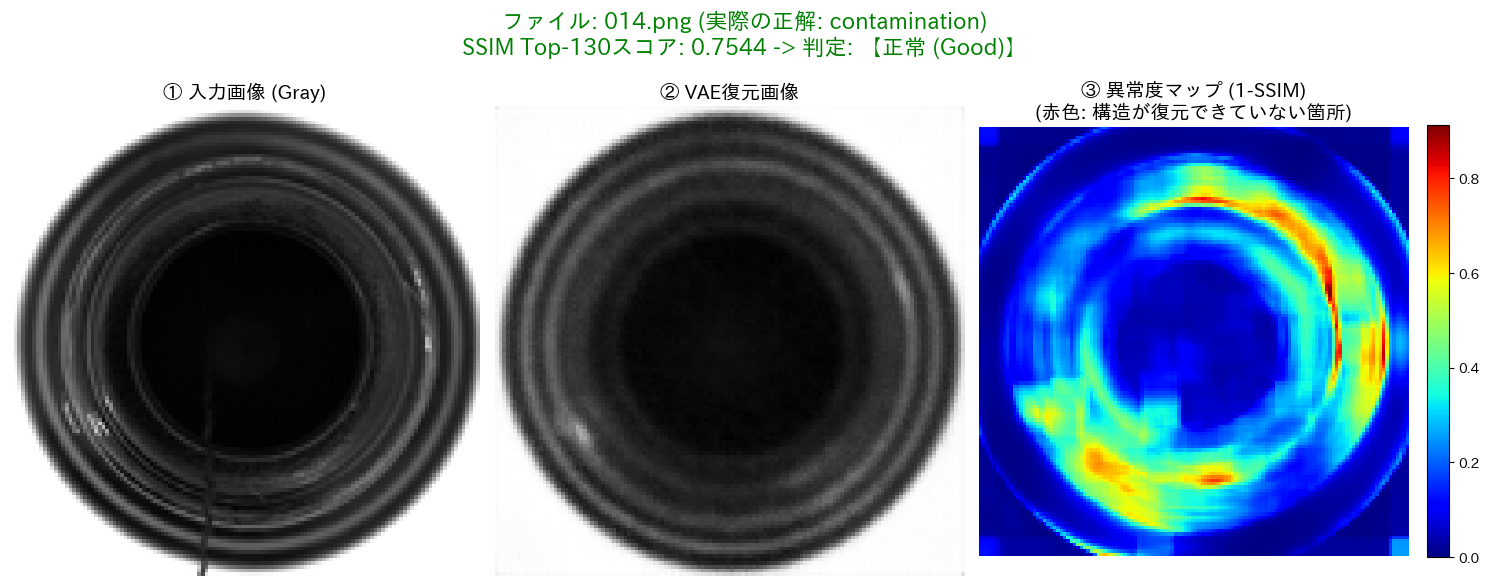


【4. TP: 異常を「異常」と正しく判断】 : 該当 58 件中 2 件を表示


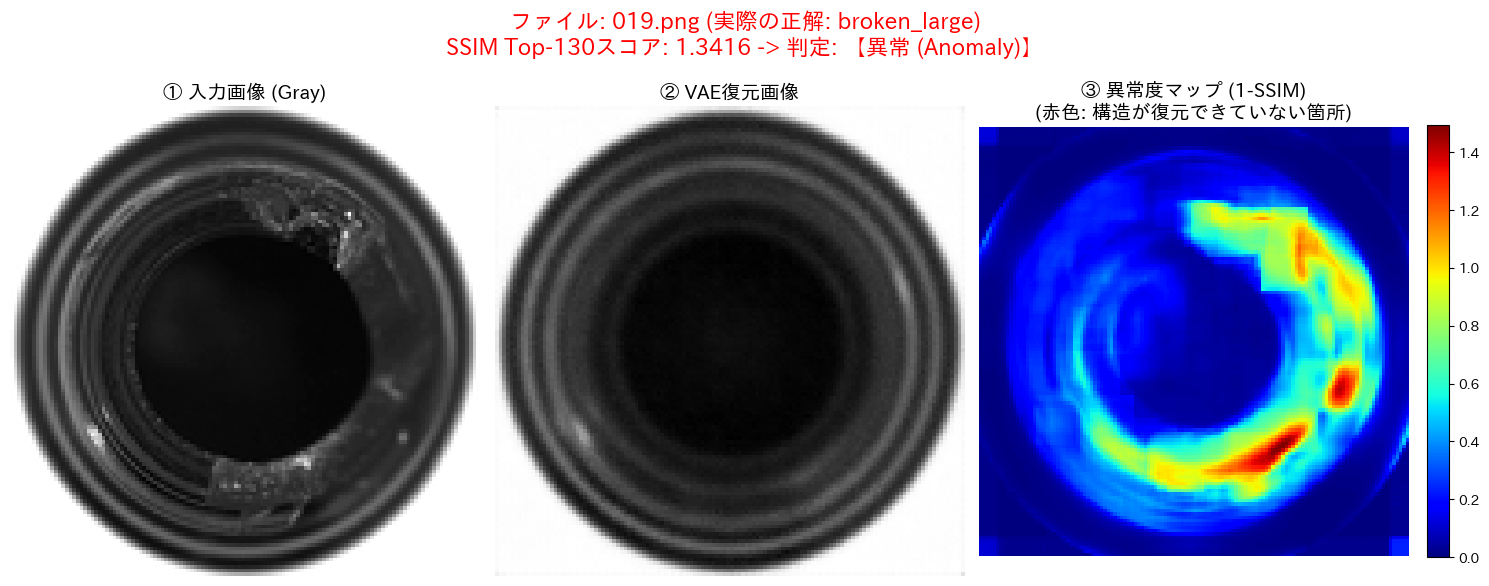

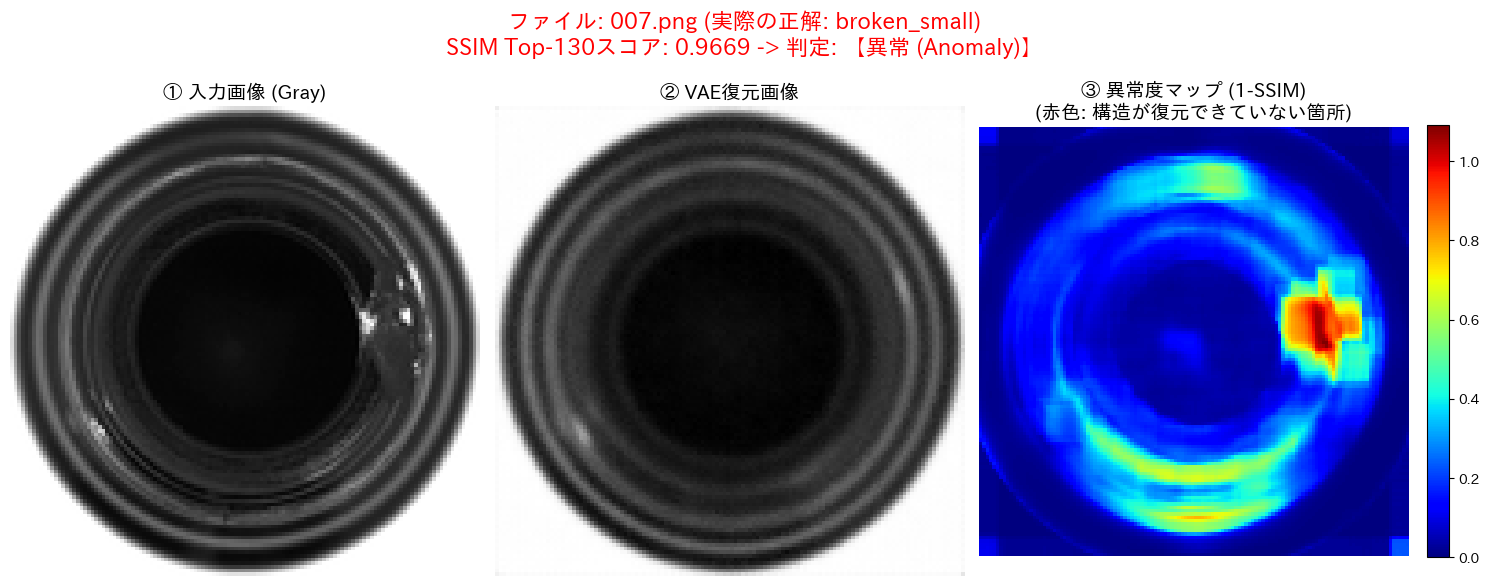


すべての検証プロセスが完了しました。


In [14]:
# =====================================================================
# 検証用スクリプト: 深いCNNモデル（VAE_CNN_Deep5）専用
# ---------------------------------------------------------------------
# - 異常スコア: SSIM Top-K (上位130パッチの平均誤差)
# - 閾値設定: F1スコアを最大化する閾値の自動探索
# - 評価指標: AUROC, F1-score, Precision, Recall, Accuracy
# =====================================================================

import random
from pathlib import Path

import torch
import torch.nn as nn
from torchvision import transforms
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from skimage.metrics import structural_similarity as ssim
from sklearn.metrics import (
    confusion_matrix, accuracy_score, recall_score, 
    precision_score, f1_score, precision_recall_curve, roc_curve, auc
)

# 日本語フォントの文字化け対策
import japanize_matplotlib
japanize_matplotlib.japanize()

# =====================================================================
# 1. 前処理とモデルの定義
# =====================================================================

# 学習時と同一の前処理パイプライン
transform = transforms.Compose([
    transforms.CenterCrop(820),
    transforms.Resize((128, 128), interpolation=transforms.InterpolationMode.LANCZOS),
    transforms.Grayscale(num_output_channels=1),
    transforms.ToTensor(),
])

class VAE_CNN_Deep5(nn.Module):
    """
    5層の深い畳み込み層を用いたVAEモデル
    """
    def __init__(self, latent_dim=64):
        super(VAE_CNN_Deep5, self).__init__()
        
        # --- エンコーダ: 畳み込み層を5層重ねてさらに深く圧縮 (128 -> 64 -> 32 -> 16 -> 8 -> 4) ---
        self.encoder_conv = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.Conv2d(16, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.Conv2d(32, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.Conv2d(128, 256, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )
        
        # 最終層のサイズ: 256チャンネル * 4ピクセル * 4ピクセル = 4096次元
        self.fc_mu = nn.Linear(256 * 4 * 4, latent_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, latent_dim)
        
        # デコーダ用の全結合層
        self.decoder_fc = nn.Linear(latent_dim, 256 * 4 * 4)
        
        # --- デコーダ: 逆畳み込み層を5層重ねて画像サイズを復元 (4 -> 8 -> 16 -> 32 -> 64 -> 128) ---
        self.decoder_conv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),

            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),

            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            
            nn.ConvTranspose2d(32, 16, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            
            nn.ConvTranspose2d(16, 1, kernel_size=4, stride=2, padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        h = self.encoder_conv(x)
        h = torch.flatten(h, start_dim=1)
        
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        
        # 潜在変数の発散(KLD爆発)を防ぐ安全装置
        logvar = torch.clamp(logvar, min=-10.0, max=10.0)
        
        std = torch.exp(0.5 * logvar)
        z = mu + torch.randn_like(std) * std
        
        h_recon = self.decoder_fc(z)
        h_recon = h_recon.view(-1, 256, 4, 4) 
        recon = self.decoder_conv(h_recon)
        
        return recon, mu, logvar

# =====================================================================
# 2. 評価・解析・可視化用 関数群
# =====================================================================

def evaluate_dataset(model, test_dir, device, top_k=130):
    """データセット全体を推論し、正解ラベル、スコア、ファイルパスを収集する"""
    model.eval()
    y_true, scores, all_image_paths = [], [], [] 
    
    test_dir = Path(test_dir)
    if not test_dir.exists():
        raise FileNotFoundError(f"テストディレクトリが見つかりません: {test_dir}\nデータパスを確認してください。")

    print(f"テストデータ全件の評価を開始します... (モデル: VAE_CNN_Deep5, Top-K: {top_k})")
    
    with torch.no_grad():
        for folder in test_dir.iterdir():
            if not folder.is_dir():
                continue
                
            true_label = 0 if folder.name == "good" else 1
            
            img_paths = list(folder.glob("*.png"))
            if not img_paths:
                continue

            for img_path in img_paths:
                img = Image.open(img_path).convert('RGB')
                input_tensor = transform(img).unsqueeze(0).to(device)

                recon_tensor, _, _ = model(input_tensor)

                input_img = input_tensor.squeeze().cpu().numpy()
                recon_img = recon_tensor.squeeze().cpu().numpy()

                # SSIMによる異常度マップの生成
                _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
                anomaly_map = 1.0 - ssim_map

                # 異常度上位Kパッチの平均をスコアとして採用
                sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
                top_k_score = np.mean(sorted_anomaly[:top_k])

                y_true.append(true_label)
                scores.append(top_k_score)
                all_image_paths.append(img_path)

    print("評価が完了しました。")
    return np.array(y_true), np.array(scores), all_image_paths


def plot_roc_curve(y_true, scores, model_name="VAE Model"):
    """ROC曲線の描画とAUROCの計算を行う"""
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 8))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUROC = {roc_auc:.4f})')
    # plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random (AUROC = 0.5)')
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (偽陽性率 / 過剰検知)', fontsize=14)
    plt.ylabel('True Positive Rate (真陽性率 / 再現率)', fontsize=14)
    plt.title(f'ROC Curve ({model_name})', fontsize=16, fontweight='bold')
    plt.legend(loc="lower right", fontsize=14)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()
    
    print(f"\n[{model_name}] AUROC: {roc_auc:.4f}")
    return roc_auc


def compute_optimal_threshold_f1(y_true, scores):
    """PR曲線からF1スコアが最大となる最適閾値を自動計算する"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    
    # ゼロ除算回避のため微小値 1e-10 を加算
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    
    print(f"\n[自動しきい値設定: F1スコア最大化]")
    print(f"-> 最適しきい値: {optimal_threshold:.4f} (Max F1: {f1_scores[optimal_idx]:.4f})")
    
    return optimal_threshold


def plot_f1_optimization(y_true, scores):
    """閾値の変化に対する各種スコアの推移と、最適閾値のポイントを可視化する"""
    precisions, recalls, thresholds = precision_recall_curve(y_true, scores)
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-10)
    
    optimal_idx = np.argmax(f1_scores)
    optimal_threshold = thresholds[optimal_idx]
    max_f1 = f1_scores[optimal_idx]

    plt.figure(figsize=(10, 6))
    
    plt.plot(thresholds, precisions[:-1], label='適合率 (Precision)', color='dodgerblue', linestyle='--')
    plt.plot(thresholds, recalls[:-1], label='再現率 (Recall)', color='darkorange', linestyle='--')
    plt.plot(thresholds, f1_scores[:-1], label='F1スコア (F1 Score)', color='forestgreen', linewidth=3)
    
    plt.axvline(x=optimal_threshold, color='red', linestyle='-', linewidth=2, 
                label=f'最適閾値: {optimal_threshold:.4f}\n(Max F1: {max_f1:.4f})')
    plt.scatter(optimal_threshold, max_f1, color='red', s=100, zorder=5) 

    plt.title('F1スコア最大化による閾値の自動探索メカニズム', fontsize=16, fontweight='bold')
    plt.xlabel('設定する閾値 (Threshold)', fontsize=14)
    plt.ylabel('評価スコア (0.0 〜 1.0)', fontsize=14)
    plt.legend(fontsize=12, loc='lower left')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix(y_true, y_pred, threshold, top_k=130):
    """混同行列と定量評価指標(正解率・適合率・再現率・F値)を描画する"""
    acc = accuracy_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)

    print(f"\n--- 定量評価結果 (VAE_CNN_Deep5) ---")
    print(f"設定閾値: {threshold:.4f}")
    print(f"正解率 (Accuracy)  : {acc * 100:.2f}%")
    print(f"適合率 (Precision) : {precision * 100:.2f}%")
    print(f"再現率 (Recall)    : {recall * 100:.2f}%")
    print(f"F値 (F1-score)     : {f1 * 100:.2f}%\n")

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['正常予測', '異常予測'],
                yticklabels=['実際の正常', '実際の異常'],
                annot_kws={"size": 16})

    title_str = (f"混同行列 (VAE_CNN_Deep5 | SSIM Top-{top_k})\n"
                 f"Acc: {acc*100:.1f}% | Precision: {precision*100:.1f}%\n"
                 f"Recall: {recall*100:.1f}% | F1: {f1*100:.1f}%")
    
    plt.title(title_str, fontsize=14)
    plt.xlabel('AIの予測', fontsize=14)
    plt.ylabel('実際の正解', fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_score_distribution(y_true, scores, threshold, top_k=130):
    """正常画像と異常画像の異常スコア分布(ヒストグラム)を描画する"""
    plt.figure(figsize=(10, 6))

    normal_scores = scores[y_true == 0]
    anomaly_scores = scores[y_true == 1]

    min_score = np.min(scores)
    max_score = np.max(scores)
    common_bins = np.linspace(min_score, max_score, 40)

    sns.histplot(normal_scores, bins=common_bins, color='green', alpha=0.5, label='正常 (Good)', kde=False)
    sns.histplot(anomaly_scores, bins=common_bins, color='red', alpha=0.5, label='異常 (Anomaly)', kde=False)

    plt.axvline(x=threshold, color='blue', linestyle='--', linewidth=2, label=f'現在の閾値 ({threshold:.4f})')

    plt.title(f"異常スコアの分布 (VAE_CNN_Deep5 | SSIM Top-{top_k})", fontsize=16, fontweight='bold')
    plt.xlabel(f"異常スコア (上位{top_k}パッチの類似度誤差平均)", fontsize=14)
    plt.ylabel("画像の数 (Count)", fontsize=14)
    plt.legend(fontsize=12)
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


def plot_single_anomaly(model, image_path, device, threshold, top_k=130):
    """1枚の画像を推論し、入力・復元・異常度マップの3パネルで可視化する"""
    model.eval()
    img = Image.open(image_path).convert('RGB')
    input_tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        recon_tensor, _, _ = model(input_tensor)

    input_img = input_tensor.squeeze().cpu().numpy()
    recon_img = recon_tensor.squeeze().cpu().numpy()

    _, ssim_map = ssim(input_img, recon_img, data_range=1.0, win_size=11, full=True)
    anomaly_map = 1.0 - ssim_map
    sorted_anomaly = np.sort(anomaly_map.flatten())[::-1]
    top_k_score = np.mean(sorted_anomaly[:top_k])

    is_anomaly = top_k_score > threshold
    judgment = "【異常 (Anomaly)】" if is_anomaly else "【正常 (Good)】"
    result_color = 'red' if is_anomaly else 'green'

    fig, axes = plt.subplots(1, 3, figsize=(15, 6))
    fig.suptitle(f"ファイル: {image_path.name} (実際の正解: {image_path.parent.name})\nSSIM Top-{top_k}スコア: {top_k_score:.4f} -> 判定: {judgment}",
                 fontsize=16, fontweight='bold', color=result_color)

    axes[0].imshow(input_img, cmap='gray')
    axes[0].set_title("① 入力画像 (Gray)", fontsize=14)
    axes[0].axis('off')

    axes[1].imshow(recon_img, cmap='gray')
    axes[1].set_title("② VAE復元画像", fontsize=14)
    axes[1].axis('off')

    vmax_val = np.max(anomaly_map) if np.max(anomaly_map) > 0.1 else 0.1
    im3 = axes[2].imshow(anomaly_map, cmap='jet', vmin=0, vmax=vmax_val)
    axes[2].set_title(f"③ 異常度マップ (1-SSIM)\n(赤色: 構造が復元できていない箇所)", fontsize=14)
    axes[2].axis('off')
    fig.colorbar(im3, ax=axes[2], fraction=0.046, pad=0.04)

    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()

# =====================================================================
# 3. 実行ブロック
# =====================================================================

if __name__ == "__main__":
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"使用デバイス: {device}")

    # --- モデルのインスタンス化と重みのロード ---
    model = VAE_CNN_Deep5(latent_dim=64).to(device)
    
    # ★ 実際の深いCNNモデルの重みファイル名に合わせて変更してください
    MODEL_PATH = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\saved_models\vae_CNN_Deep5_Annealing_ep100_beta50_128.pth"

    if not Path(MODEL_PATH).exists():
        raise FileNotFoundError(f"重みファイルが見つかりません: {MODEL_PATH}\n学習が完了しているか確認してください。")

    model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
    print(f"VAE_CNN_Deep5 の重みを読み込みました。\n")

    # --- テスト設定 ---
    TEST_DIR = r"C:\Users\tokiy\my_GitHub\image-anomaly-detection\data\bottle\test"
    TOP_K = 130

    # --- 検証プロセスの実行 ---

    # 1. 全画像の異常スコアを算出
    y_true, scores, all_image_paths = evaluate_dataset(model, TEST_DIR, device, top_k=TOP_K)

    # 2. AUROCの計算と描画（閾値非依存の性能評価）
    auroc_score = plot_roc_curve(y_true, scores, model_name="VAE_CNN_Deep5")

    # 3. F1スコアが最大となる最適閾値を探索
    THRESHOLD = compute_optimal_threshold_f1(y_true, scores)
    
    # 4. F1最適化の推移を図解
    plot_f1_optimization(y_true, scores)

    # 5. 決定した閾値に基づく最終的な予測ラベルを作成
    y_pred = (scores > THRESHOLD).astype(int)

    # 6. 定量評価・スコア分布の描画
    plot_confusion_matrix(y_true, y_pred, THRESHOLD, top_k=TOP_K)
    plot_score_distribution(y_true, scores, THRESHOLD, top_k=TOP_K)

    # --- 各判定パターン（TP/FP/TN/FN）ごとの画像確認 ---
    print("\n--- パターン別の代表例を可視化します ---")
    tn_paths, fp_paths, fn_paths, tp_paths = [], [], [], []
    for true_lbl, pred_lbl, path in zip(y_true, y_pred, all_image_paths):
        if true_lbl == 0 and pred_lbl == 0: tn_paths.append(path)
        elif true_lbl == 0 and pred_lbl == 1: fp_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 0: fn_paths.append(path)
        elif true_lbl == 1 and pred_lbl == 1: tp_paths.append(path)

    categories = {
        "【1. TN: 正常を「正常」と正しく判断】": tn_paths,
        "【2. FP: 正常を「異常」と誤って判断 (過剰検知)】": fp_paths,
        "【3. FN: 異常を「正常」と誤って判断 (見逃し)】": fn_paths,
        "【4. TP: 異常を「異常」と正しく判断】": tp_paths
    }

    for title, paths in categories.items():
        sample_size = min(2, len(paths))
        print(f"\n{title} : 該当 {len(paths)} 件中 {sample_size} 件を表示")

        if sample_size > 0:
            sampled_paths = random.sample(paths, sample_size)
            for img_path in sampled_paths:
                plot_single_anomaly(model, img_path, device, THRESHOLD, top_k=TOP_K)
        else:
            print("  -> このパターンに該当する画像はありません。")

    print("\nすべての検証プロセスが完了しました。")